# CPSR: Sparse SYK-4 Edge-of-Chaos Quantum Reservoir in Qiskit

**Builds on:** `CPSR_EdgeOfChaos_Reservoir_Qiskit.ipynb` (the QELM edge-of-chaos
notebook) and, transitively, `Quantum_Reservoir_Qiskit.ipynb`. Sections 0a and
0b below are copied **verbatim, unchanged** -- same as that notebook -- and
nothing in this notebook edits, wraps, or bypasses that code.

**Why this notebook exists.** The QELM notebook's own finite-size check found
the adjacent-gap ratio `<r>` pinned at the Poisson reference across every
coupling `g` and every `N` tested (6, 8, 10): the reservoir's entangling layer
is a **2-body** interaction (nearest-neighbor `CPhase` plus single-qubit
fields), which under a Jordan-Wigner mapping is a quadratic -- i.e.
free-fermion-equivalent, exactly solvable, **SYK-2-like** -- Hamiltonian. SYK-2
is integrable by construction; no amount of tuning `g` or `N` makes it
genuinely chaotic. Real many-body quantum chaos (and the SYK model's defining
physics) requires **4-body**, randomly-coupled, all-to-all interactions --
SYK-4.

**What this notebook adds, as a new mode built ON TOP OF the unchanged
Section 0a/0b code (Section 0c):** a **sparse random SYK-4 entangling layer**
-- `M ~ N*ln(N)` randomly chosen 4-qubit `Z_iZ_jZ_kZ_l` rotations (each an
exact, Trotter-error-free phase-kickback gadget: 6 CNOTs + 1 `Rz`, since all
`ZZZZ` terms commute) with i.i.d. Gaussian couplings `J_{ijkl}`, replacing the
QELM architecture's 2-body `CPhase`-chain entangler while keeping its
reset-every-step / sliding-window encoding and exact-expectation-value readout
(`feature_ops_all`, Section 0a) untouched. This is a "sparse SYK" construction
(a random subset of the complete 4-body hypergraph, following the sparse-SYK
literature's finding that a small fraction of the `C(N,4)` possible terms
already recovers genuine chaos at a fraction of the gate cost).

Section flow mirrors `CPSR_EdgeOfChaos_Reservoir_Qiskit.ipynb` exactly (0a, 0b,
configuration demo, diagnostics, unit tests, coupling scan, performance
impact, finite-size check, hardware, summary) so the two notebooks are directly
comparable side by side, coupling `g` (2-body) vs. coupling `J` (sparse 4-body).

**Headline result, confirmed in a standalone prototype before this notebook was
written:** sweeping `J` at fixed `N=6-10` and a SPARSE (11-24% of complete)
random 4-body term set pushes `<r>` from ~0.39 (Poisson, exactly what the
2-body model gave) up to ~0.51-0.53 -- landing ON the COE reference band
(~0.53) -- with the match tightening as `N` grows from 8 to 10. This notebook
verifies that quantitatively (Sections 2-6) rather than asserting it, with
unit tests (Section 3) gating every sweep.


## Setup

In [1]:
# Uncomment on a fresh environment:
# %pip install "qiskit>=1.2" qiskit-aer qiskit-ibm-runtime scikit-learn numpy scipy matplotlib


In [2]:
from __future__ import annotations

import functools
import itertools
from math import comb
import os
import time
from dataclasses import dataclass
from typing import Sequence

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, unitary_group

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Pauli, Operator, Statevector

import qiskit
import qiskit_aer  # noqa: F401  -- import needed to register .save_expectation_value on QuantumCircuit
from qiskit_aer import AerSimulator

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

print('numpy', np.__version__, ' scipy', __import__('scipy').__version__)
print('qiskit', qiskit.__version__, ' qiskit-aer', qiskit_aer.__version__)


numpy 2.5.2  scipy 1.18.1
qiskit 2.5.2  qiskit-aer 0.17.2


## Section 0a -- Reservoir module (verbatim, unchanged, from `Quantum_Reservoir_Qiskit.ipynb`)

Copied exactly as written there. `feature_ops_all` (the full `3^w`-weight
Pauli-string readout) is reused unchanged for the SYK-4 mode's readout in
Section 0c below -- readout is architecture-independent.


In [3]:
"""
This module implements *only* the reservoir itself:
  - ONE fixed *nearest-neighbor-chain topology (no topology sweep/optimization)*
  - ONE fixed coupling strength `g` (no "edge of chaos" / critical-phase scan;
    g is just a hyperparameter you can tune, with no special physical claim
    attached to any particular value)
  - EXACT expectation-value readout, computed directly by Aer's
    `save_expectation_value` (no classical-shadow / randomized-measurement
    estimation)
"""

# =============================================================================
# 1. Reservoir configuration and circuit construction
# =============================================================================

def chain_edges(N: int):
    """Nearest-neighbor chain -- the one fixed topology used throughout."""
    return [(i, i + 1) for i in range(N - 1)]


@dataclass
class ReservoirConfig:
    N: int = 6                     # <-- INCREASE QUBIT COUNT HERE
    g: float = 0.6                 # entangling coupling angle (radians), fixed
    reps: int = 2                  # entangling+disorder block repetitions per timestep
    input_qubit: int = 0           # qubit reset + re-encoded with u_t every step
    seed: int = 42                 # fixes the random disorder (bias_z, bias_x)

    # `g` and `reps` above were picked by a one-time check of validation-block
    # NRMSE across a small grid (g in {0.3,0.6,0.94,1.2,1.57} rad x reps in
    # {1,2,3}), NOT by scanning for a claimed "critical"/"edge of chaos" point
    # and NOT swept per-experiment -- see the module docstring's SCOPE note.

    def sample_disorder(self):
        rng = np.random.RandomState(self.seed)
        bias_z = rng.uniform(0, 2 * np.pi, self.N)
        bias_x = rng.uniform(0.3, 0.7, self.N)
        return bias_z, bias_x


def reservoir_layer(qc: QuantumCircuit, N: int, g: float, bias_z, bias_x):
    """One entangling + disorder layer on the fixed chain topology.

    U = Rx(bias_x) . Rz(bias_z) . CPhase(2g)_chain, applied left-to-right as a
    circuit (so the entangling bricks go first). `g` is just a coupling
    strength here -- not swept, not framed as a phase transition.
    """
    for a, b in chain_edges(N):
        qc.cp(2.0 * g, a, b)
    for i in range(N):
        qc.rz(bias_z[i], i)
    for i in range(N):
        qc.rx(bias_x[i], i)


def feature_ops(N: int, input_qubit: int):
    """Local Pauli readout operators: X/Y/Z on every memory qubit (everything
    except `input_qubit`) plus nearest-neighbor ZZ correlators among them.

    These are read out EXACTLY (Aer computes them directly from the
    statevector/density matrix) -- there is no shot noise and no classical-
    shadow estimator here. That is a deliberate simplification: this module
    benchmarks the reservoir's computational quality, not a shot-limited
    hardware read-out protocol.
    """
    mem = [q for q in range(N) if q != input_qubit]
    ops, labels = [], []
    for q in mem:
        for name in ('Z', 'X', 'Y'):
            ops.append((Pauli(name), [q]))
            labels.append(f'{name}{q}')
    for a, b in zip(mem[:-1], mem[1:]):
        ops.append((Pauli('ZZ'), [a, b]))
        labels.append(f'Z{a}Z{b}')
    return labels, ops


def build_trajectory_circuit(cfg: ReservoirConfig, u_seq: Sequence[float]):
    """Build ONE circuit for the entire recurrent trajectory.

    Each timestep: reset the input qubit (discard its old state -> fading
    memory), inject u_t via a Ry rotation, apply the reservoir layer(s), and
    snapshot every feature's exact expectation value with a labeled
    `save_expectation_value`. The memory register is never reset, so its
    state at step t carries forward everything the unitary dynamics retained
    from steps < t.

    Doing the whole trajectory as one circuit (rather than T separate Python-
    level evolve() calls) lets the entire recurrence run inside Aer's C++/CUDA
    engine in a single `.run()` call -- which is what makes the GPU device
    switch in `run_reservoir` actually matter for wall-clock time.
    """
    bias_z, bias_x = cfg.sample_disorder()
    labels, ops = feature_ops(cfg.N, cfg.input_qubit)
    qc = QuantumCircuit(cfg.N)
    for t, u_t in enumerate(u_seq):
        qc.reset(cfg.input_qubit)
        qc.ry(np.pi * float(u_t), cfg.input_qubit)
        for _ in range(cfg.reps):
            reservoir_layer(qc, cfg.N, cfg.g, bias_z, bias_x)
        for (op, qargs), lab in zip(ops, labels):
            qc.save_expectation_value(op, qargs, label=f'{lab}__t{t}')
    return qc, labels


# =============================================================================
# 2a. CPU/GPU execution
# =============================================================================

def make_simulator(use_gpu: bool = False, method: str = 'density_matrix') -> AerSimulator:
    """Build the Aer backend. This is the ONLY place device selection happens.

    `method='density_matrix'` is required for the reset-based fading-memory
    architecture above (resetting one qubit of an entangled *pure* state
    produces a mixed state in general, so a plain Statevector cannot represent
    it -- see the SCALING NOTES below for the statevector-only alternative and
    what it costs you).
    """
    device = 'GPU' if use_gpu else 'CPU'
    if use_gpu:
        # Gotcha: AerSimulator(device='GPU').available_devices() just ECHOES
        # BACK the device it was already configured with -- it does not
        # actually probe hardware/build support (verified empirically; see
        # notebook Section 2). The only reliable check is to ask a freshly
        # constructed, unconfigured simulator what it truly supports.
        available = AerSimulator().available_devices()
        if 'GPU' not in available:
            raise RuntimeError(
                "USE_GPU=True but this qiskit-aer build has no GPU device "
                f"(available devices on a fresh AerSimulator(): {available}).\n"
                "qiskit-aer's PyPI wheels for Windows are CPU-only. To get the GPU "
                "device you need either:\n"
                f"  (a) WSL2 / native Linux + `pip install qiskit-aer-gpu-cu11` "
                f"(matches this repo's qiskit-aer=={qiskit_aer.__version__}), or\n"
                "  (b) build qiskit-aer from source against your local CUDA toolkit "
                "(see qiskit.org/ecosystem/aer build docs).\n"
                "Set USE_GPU = False to run on CPU in the meantime."
            )
    return AerSimulator(method=method, device=device)


def run_reservoir(cfg: ReservoirConfig, u_seq: Sequence[float], use_gpu: bool = False,
                   use_qpu: bool = False, method: str = 'density_matrix', **qpu_kwargs):
    """Execute the full recurrent trajectory once. Returns (labels, X, info).

    X has shape (T, n_features); info carries timing + circuit-resource data
    so CPU vs GPU vs QPU (or N vs N') runs can be compared honestly.

    `use_qpu=True` routes to `run_reservoir_qpu` (real IBM hardware) instead
    of Aer -- a genuinely different execution path, not just a device string;
    see that function's docstring. `**qpu_kwargs` (backend_name, service,
    shots, optimization_level, max_circuits) are forwarded to it and ignored
    otherwise.
    """
    # if use_qpu:
    #     return run_reservoir_qpu(cfg, u_seq, **qpu_kwargs)

    qc, labels = build_trajectory_circuit(cfg, u_seq)
    sim = make_simulator(use_gpu=use_gpu, method=method)
    tqc = transpile(qc, sim)

    t0 = time.perf_counter()
    result = sim.run(tqc, shots=1).result()
    elapsed = time.perf_counter() - t0

    data = result.data(0)
    T = len(u_seq)
    X = np.empty((T, len(labels)))
    for t in range(T):
        for j, lab in enumerate(labels):
            X[t, j] = np.real(data[f'{lab}__t{t}'])

    info = {
        'device': 'GPU' if use_gpu else 'CPU',
        'method': method,
        'N': cfg.N,
        'T': T,
        'elapsed_s': elapsed,
        'steps_per_s': T / elapsed if elapsed > 0 else float('inf'),
        'circuit_depth': tqc.depth(),
        'circuit_size': tqc.size(),
        'n_features': len(labels),
    }
    return labels, X, info


# =============================================================================
# 2b. Real IBM hardware execution (USE_QPU)
# =============================================================================
# This is a genuinely different code path from CPU/GPU, not a device swap:
# Aer's `save_expectation_value` (Section 2) is a SIMULATOR-ONLY instruction
# that snapshots mid-circuit state without collapsing it -- real QPUs have no
# such thing, and cannot persist a quantum state between separate circuit
# executions the way one big Aer circuit does across T reset-and-continue
# steps. So on real hardware, the state at step t has to be recreated from
# scratch by literally replaying the ENTIRE prefix u_1..u_t inside ONE
# circuit that ends with an end-of-circuit expectation-value read via the
# Estimator primitive. Circuit depth for step t is O(t); summed over a
# T-step trajectory that is O(T^2) total gates -- which is why `max_circuits`
# below defaults small and a hardware run should use a much shorter T than
# the CPU/GPU benchmarks in this module use.

DEFAULT_QPU_BACKEND = 'ibm_marrakesh'

def get_ibm_service() -> 'QiskitRuntimeService':
    """Authenticate against IBM Quantum ONLY from environment variables --
    never hard-code a token or CRN here or in a notebook (review comment 13).

    Reads:
        IBM_QUANTUM_TOKEN     your IBM Cloud API token
        IBM_QUANTUM_INSTANCE  your IBM Cloud CRN (Cloud Resource Name) for the
                               Quantum Compute service instance

    Set these in your shell -- e.g. on Windows:
        setx IBM_QUANTUM_TOKEN "..."
        setx IBM_QUANTUM_INSTANCE "crn:v1:bluemix:public:quantum-computing:..."
    (restart your shell/kernel afterwards) -- or on Linux/macOS:
        export IBM_QUANTUM_TOKEN=...
        export IBM_QUANTUM_INSTANCE=crn:...

    This function does NOT call `QiskitRuntimeService.save_account(...)` --
    it authenticates in-memory for this process only, so nothing is written
    to disk beyond what you already put in your environment. If you'd rather
    persist an account to Qiskit's config store, call `save_account` yourself
    (see the qiskit-ibm-runtime docs); that is a deliberate choice this
    module leaves to you rather than doing on your behalf.
    """
    token = os.environ.get('IBM_QUANTUM_TOKEN')
    instance = os.environ.get('IBM_QUANTUM_INSTANCE')
    if not token or not instance:
        missing = [n for n, v in (('IBM_QUANTUM_TOKEN', token), ('IBM_QUANTUM_INSTANCE', instance)) if not v]
        raise RuntimeError(
            "USE_QPU=True requires IBM Quantum credentials as environment variables "
            f"-- missing: {', '.join(missing)}.\n"
            "Set IBM_QUANTUM_TOKEN (your IBM Cloud API token) and IBM_QUANTUM_INSTANCE "
            "(your IBM Cloud CRN for the Quantum Compute service instance), then restart "
            "your shell/notebook kernel. Credentials are never hard-coded in this repo "
            "(review comment 13)."
        )
    from qiskit_ibm_runtime import QiskitRuntimeService
    return QiskitRuntimeService(channel='ibm_quantum_platform', token=token, instance=instance)


def _pauli_to_sparse_op(N: int, pauli: Pauli, qargs):
    """Convert one `feature_ops`-style (Pauli, qargs) pair into an N-qubit
    `SparsePauliOp`, for the Estimator primitive (identity elsewhere)."""
    from qiskit.quantum_info import SparsePauliOp
    return SparsePauliOp.from_sparse_list([(pauli.to_label(), qargs, 1.0)], num_qubits=N)


def build_hardware_circuits(cfg: ReservoirConfig, u_seq: Sequence[float]):
    """One circuit per timestep t, each replaying the FULL prefix u_1..u_t
    from |0..0> (see the section note above for why). Returns
    (circuits, observables, labels) -- `observables` is shared across all
    circuits (same feature set every step); `labels[j]` names
    `observables[j]`.
    """
    bias_z, bias_x = cfg.sample_disorder()
    labels, ops = feature_ops(cfg.N, cfg.input_qubit)
    observables = [_pauli_to_sparse_op(cfg.N, op, qargs) for (op, qargs) in ops]

    circuits = []
    for t in range(1, len(u_seq) + 1):
        qc = QuantumCircuit(cfg.N)
        for u_t in u_seq[:t]:
            qc.reset(cfg.input_qubit)
            qc.ry(np.pi * float(u_t), cfg.input_qubit)
            for _ in range(cfg.reps):
                reservoir_layer(qc, cfg.N, cfg.g, bias_z, bias_x)
        circuits.append(qc)
    return circuits, observables, labels


def run_reservoir_qpu(cfg: ReservoirConfig, u_seq: Sequence[float],
                       backend_name: str = DEFAULT_QPU_BACKEND, service=None,
                       shots: int = 4096, optimization_level: int = 3,
                       max_circuits: int = 25):
    """Run the recurrent trajectory on a real IBM QPU (default: `ibm_marrakesh`,
    pinned by name -- no silent `least_busy()` substitution, per comment 9).

    `max_circuits` is a deliberate, small default safety cap: each extra
    timestep is a full prefix-replay circuit (see the section note above), so
    T timesteps cost O(T^2) total two-qubit gates on a real, rate/cost-limited
    device. Raise it explicitly if you really want a longer run.

    Returns (labels, X, info); `info` reports backend name/version, job id,
    per-circuit depth and two-qubit-gate count (growing with t), and total
    two-qubit gates across the whole job, so the hardware cost of this run is
    visible rather than hidden (comment 9-11's spirit: report real resources).
    """
    if len(u_seq) > max_circuits:
        raise ValueError(
            f"len(u_seq)={len(u_seq)} exceeds max_circuits={max_circuits}. Real hardware "
            "cost grows O(T^2) here (see run_reservoir_qpu's docstring) -- this cap exists "
            "so a long T isn't submitted to paid/rate-limited hardware by accident. Pass a "
            "larger max_circuits explicitly if you intend that."
        )

    from qiskit_ibm_runtime import EstimatorV2
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    service = service or get_ibm_service()
    backend = service.backend(backend_name)

    circuits, observables, labels = build_hardware_circuits(cfg, u_seq)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=optimization_level)
    isa_circuits = [pm.run(qc) for qc in circuits]
    isa_observables = [[obs.apply_layout(ic.layout) for obs in observables] for ic in isa_circuits]
    pubs = list(zip(isa_circuits, isa_observables))

    estimator = EstimatorV2(mode=backend)
    estimator.options.default_shots = shots

    t0 = time.perf_counter()
    job = estimator.run(pubs)
    result = job.result()
    elapsed = time.perf_counter() - t0

    X = np.array([np.real(pub_result.data.evs) for pub_result in result])

    depths = [ic.depth() for ic in isa_circuits]
    twoq_counts = [sum(v for k, v in ic.count_ops().items() if k in ('cz', 'ecr', 'cx', 'rzz'))
                   for ic in isa_circuits]
    info = {
        'device': 'QPU', 'backend': backend.name,
        'backend_num_qubits': backend.num_qubits,
        'job_id': job.job_id(),
        'N': cfg.N, 'T': len(u_seq), 'shots': shots,
        'elapsed_s': elapsed,
        'steps_per_s': len(u_seq) / elapsed if elapsed > 0 else float('inf'),
        'circuit_depth_per_step': depths,
        'circuit_depth_final': depths[-1] if depths else 0,
        'two_qubit_gates_per_step': twoq_counts,
        'two_qubit_gates_total': int(sum(twoq_counts)),
        'n_features': len(labels),
    }
    return labels, X, info


# =============================================================================
# 2c. Memoryless QELM execution (SCALING NOTE option 1: statevector, higher N)
# =============================================================================
# Sections 1-2b above are the genuinely recurrent architecture: ONE qubit
# (`input_qubit`) is reset and re-encoded each step while the rest of the
# register is never reset, so the state is generally MIXED and needs Aer's
# method='density_matrix' (4**N cost). This section drops that: reset EVERY
# qubit each step (so the state stays PURE and method='statevector', 2**N
# cost, becomes valid -- roughly doubling the reachable N for the same memory
# budget), and recover "memory" only from re-encoding a classical sliding
# window of recent inputs. This is a Quantum Extreme Learning Machine (QELM):
# a memoryless feature map, not a memory -- any nonzero memory-capacity score
# from it reflects the classical window, NOT information retained by the
# quantum state (contrast with comment 1's fix in Section 1). Same
# window/slot-phase scheme as `idcpsr_qiskit.py`'s `reservoir_states_qiskit`,
# reimplemented here as one Aer circuit with exact `save_expectation_value`
# readout so it plugs into the same benchmark harness (Section 0b) as the
# recurrent reservoir above.

def feature_ops_all(N: int, max_weight: int = 3):
    """Local Pauli readout operators: the FULL 3**w Pauli-string basis
    (every combination of X/Y/Z, not just all-Z) on every adjacent window of
    w<=max_weight qubits, for w=1 (every qubit) up through w=max_weight
    (every adjacent w-tuple).

    Why the full basis, not just Z/ZZ/ZZZ: after `build_qelm_circuit`'s
    per-step disorder rotation (bias_z, bias_x, fixed but qubit-specific), a
    single qubit's Bloch vector is a FIXED rotation of (sin(theta), 0,
    cos(theta)), so <Z> alone is no longer cos(theta) -- but <X>, <Y>, <Z>
    TOGETHER remain an exactly invertible linear image of (sin(theta),
    cos(theta)) for any fixed rotation. The same holds jointly for a
    w-qubit PRODUCT state: <P1 P2 ... Pw> for the right combination of
    Paulis linearly spans everything needed to reconstruct
    prod_j cos(theta_j) via ridge -- but only if enough of the 3**w
    combinations are actually read out. Reading out only the all-Z
    correlator (as an earlier version of this function did) discards most of
    that span, which is exactly why k-Pauli tasks with k>=2 fit poorly
    without this: see `run_reservoir_qelm`'s docstring for the empirical
    comparison. `max_weight=3` matches this module's k-Pauli benchmark's
    `k_list=(1,2,3)` -- no higher-weight terms are needed for k<=3, so none
    are computed.
    """
    ops, labels = [], []
    paulis = ('Z', 'X', 'Y')
    for q in range(N):
        for name in paulis:
            ops.append((Pauli(name), [q]))
            labels.append(f'{name}{q}')
    if max_weight >= 2:
        for a, b in zip(range(N - 1), range(1, N)):
            for p1, p2 in itertools.product(paulis, repeat=2):
                ops.append((Pauli(p1 + p2), [a, b]))
                labels.append(f'{p1}{a}{p2}{b}')
    if max_weight >= 3:
        for a in range(N - 2):
            for p1, p2, p3 in itertools.product(paulis, repeat=3):
                ops.append((Pauli(p1 + p2 + p3), [a, a + 1, a + 2]))
                labels.append(f'{p1}{a}{p2}{a + 1}{p3}{a + 2}')
    return labels, ops


def build_qelm_circuit(cfg: ReservoirConfig, u_seq: Sequence[float], window_size: int = 8,
                        max_weight: int = 3, reps: int = 1, g: float = 0.05):
    """Build ONE circuit for the entire trajectory, memoryless-QELM style.

    Each timestep: reset ALL N qubits to |0..0> (not just `input_qubit` as in
    `build_trajectory_circuit`), so the state is pure going into every step's
    encoding. `u_t` is placed into a length-min(window_size, N) sliding
    window of the most recent inputs, mapped 1:1 onto qubits 0..window-1 (NOT
    `w % N` -- wrapping onto qubits that already hold a different lag would
    ADD the two lags' rotation angles together on the same qubit, corrupting
    both; capping the window at N and dropping older lags instead keeps every
    retained lag on its own qubit). Then `reps` reservoir layers (using `g`,
    NOT `cfg.g`/`cfg.reps` -- see below) are applied and every feature's
    exact expectation value is snapshotted, exactly as in
    `build_trajectory_circuit`.

    `reps`/`g` are QELM's OWN entangling depth/strength, deliberately
    decoupled from `cfg.reps`/`cfg.g` (which the genuinely recurrent
    architecture in Section 1 uses): a validation-block sweep (same one-time
    grid-check spirit as `ReservoirConfig`'s own `g`/`reps` choice) over
    reps in {0,1,2,3} x g in {0, 0.05, ..., 0.6} found that MORE entangling
    here actively HURTS the k-Pauli tasks -- each `reservoir_layer` rotates
    every qubit's Bloch vector by more disorder, widening the gap between
    what `feature_ops_all`'s finite (weight<=3) Pauli-string basis can
    linearly represent and the target's exact trigonometric form. `reps=1,
    g=0.05` was the smallest step past `reps=0` (which reduces to a purely
    classical, exactly-solvable cosine-product feature map -- see
    `run_reservoir_qelm`'s docstring) that still exercises genuine multi-qubit
    entangling gates while keeping k-Pauli NRMSE robustly low (not merely
    low on one lucky ridge-alpha tie-break) across N=4..10.
    """
    bias_z, bias_x = cfg.sample_disorder()
    labels, ops = feature_ops_all(cfg.N, max_weight=max_weight)
    eff_window = min(window_size, cfg.N)
    slot_to_qubit = list(range(eff_window))

    qc = QuantumCircuit(cfg.N)
    for t, _ in enumerate(u_seq):
        lo = max(0, t - eff_window + 1)
        wlen = t - lo + 1
        window = np.zeros(eff_window)
        window[-wlen:] = u_seq[lo:t + 1]
        per_q = np.zeros(cfg.N)
        for w, uu in enumerate(window):
            per_q[slot_to_qubit[w]] += np.pi * float(uu)

        for i in range(cfg.N):
            qc.reset(i)
            qc.ry(per_q[i], i)
        for _ in range(reps):
            reservoir_layer(qc, cfg.N, g, bias_z, bias_x)
        for (op, qargs), lab in zip(ops, labels):
            qc.save_expectation_value(op, qargs, label=f'{lab}__t{t}')
    return qc, labels


def run_reservoir_qelm(cfg: ReservoirConfig, u_seq: Sequence[float], window_size: int = 8,
                        max_weight: int = 3, reps: int = 1, g: float = 0.05,
                        use_gpu: bool = False, use_qpu: bool = False,
                        method: str = 'statevector', **qpu_kwargs):
    """Execute the memoryless QELM trajectory once. Same (labels, X, info)
    return shape as `run_reservoir`, so it drops into the same benchmark
    harness (`run_benchmark(..., reservoir_fn=...)`).

    `method='statevector'` is the point of this variant (see SCALING NOTES) --
    passing `method='density_matrix'` still works (a full per-step reset
    keeps the state pure either way) but gives up the 2**N-vs-4**N memory
    saving that is the whole reason to use it.

    `reps`/`g` (QELM's own entangling depth/strength, default 1/0.05 --
    see `build_qelm_circuit`'s docstring) trade off against k-Pauli accuracy:
    `reps=0` (no entangling at all) makes this an EXACTLY solvable, purely
    classical cosine-product feature map (k-Pauli NRMSE -> 0 for k<=max_weight,
    but zero genuine quantum computation happens); the shipped defaults are
    the smallest step past that which still runs real entangling gates while
    keeping k-Pauli NRMSE robustly low (see the module's benchmark results).
    Raising `g`/`reps` back toward `cfg.g`/`cfg.reps` (0.6/2, used by the
    recurrent architecture) measurably degrades k-Pauli fits -- more
    disorder-rotation per step widens the gap between what the finite
    (`max_weight`-bounded) Pauli-string readout can linearly represent and
    the target's exact trigonometric form.

    `use_qpu=True` routes to `run_reservoir_qelm_qpu` (real IBM hardware)
    instead of Aer, mirroring `run_reservoir`'s `use_qpu` dispatch.
    `**qpu_kwargs` (backend_name, service, shots, optimization_level,
    max_circuits) are forwarded to it and ignored otherwise.
    """
    if use_qpu:
        return run_reservoir_qelm_qpu(cfg, u_seq, window_size=window_size, max_weight=max_weight,
                                       reps=reps, g=g, **qpu_kwargs)

    qc, labels = build_qelm_circuit(cfg, u_seq, window_size=window_size, max_weight=max_weight,
                                     reps=reps, g=g)
    sim = make_simulator(use_gpu=use_gpu, method=method)
    tqc = transpile(qc, sim)

    t0 = time.perf_counter()
    result = sim.run(tqc, shots=1).result()
    elapsed = time.perf_counter() - t0

    data = result.data(0)
    T = len(u_seq)
    X = np.empty((T, len(labels)))
    for t in range(T):
        for j, lab in enumerate(labels):
            X[t, j] = np.real(data[f'{lab}__t{t}'])

    info = {
        'device': 'GPU' if use_gpu else 'CPU',
        'method': method,
        'architecture': 'qelm_statevector',
        'window_size': window_size,
        'N': cfg.N,
        'T': T,
        'elapsed_s': elapsed,
        'steps_per_s': T / elapsed if elapsed > 0 else float('inf'),
        'circuit_depth': tqc.depth(),
        'circuit_size': tqc.size(),
        'n_features': len(labels),
    }
    return labels, X, info


# -----------------------------------------------------------------------------
# 2d. QELM real IBM hardware execution (USE_QPU)
# -----------------------------------------------------------------------------
# The recurrent architecture's hardware path (Section 2b) has to replay the
# ENTIRE input prefix u_1..u_t inside one circuit per timestep, because Aer's
# mid-circuit save_expectation_value has no real-hardware equivalent and a
# real QPU cannot persist a quantum state between circuit executions -- hence
# O(t) depth per step, O(T^2) total gates. The QELM architecture does NOT
# have that problem: every qubit is reset each step anyway (see
# `build_qelm_circuit`), so the state at step t depends ONLY on the current
# `window_size`-wide window, not on anything before it. Each hardware circuit
# below is therefore a single fresh encode-then-reservoir-layers circuit --
# CONSTANT depth in t, O(T) total gates across the whole trajectory, no
# prefix replay needed.

def build_qelm_hardware_circuits(cfg: ReservoirConfig, u_seq: Sequence[float], window_size: int = 8,
                                  max_weight: int = 3, reps: int = 1, g: float = 0.05):
    """One circuit per timestep t for the QELM variant on real hardware.
    Unlike `build_hardware_circuits` (recurrent architecture), no prefix
    replay is needed -- see the section note above. Same no-aliasing window
    mapping, full-Pauli-string readout (`feature_ops_all`, `max_weight`), and
    `reps`/`g` defaults as `build_qelm_circuit` -- see its docstring. Returns
    (circuits, observables, labels), same shape as `build_hardware_circuits`.

    Note: `max_weight=3`'s full Pauli-string basis means many more distinct
    observables per circuit than the earlier all-Z-only design (93-327 for
    N=4..10) -- `EstimatorV2` groups these into compatible measurement bases
    automatically, but real-hardware jobs cost more (more distinct bases to
    sample) than a smaller observable set would.
    """
    bias_z, bias_x = cfg.sample_disorder()
    labels, ops = feature_ops_all(cfg.N, max_weight=max_weight)
    observables = [_pauli_to_sparse_op(cfg.N, op, qargs) for (op, qargs) in ops]
    eff_window = min(window_size, cfg.N)
    slot_to_qubit = list(range(eff_window))

    circuits = []
    for t in range(len(u_seq)):
        lo = max(0, t - eff_window + 1)
        wlen = t - lo + 1
        window = np.zeros(eff_window)
        window[-wlen:] = u_seq[lo:t + 1]
        per_q = np.zeros(cfg.N)
        for w, uu in enumerate(window):
            per_q[slot_to_qubit[w]] += np.pi * float(uu)

        qc = QuantumCircuit(cfg.N)
        for i in range(cfg.N):
            qc.ry(per_q[i], i)
        for _ in range(reps):
            reservoir_layer(qc, cfg.N, g, bias_z, bias_x)
        circuits.append(qc)
    return circuits, observables, labels


def run_reservoir_qelm_qpu(cfg: ReservoirConfig, u_seq: Sequence[float], window_size: int = 8,
                            max_weight: int = 3, reps: int = 1, g: float = 0.05,
                            backend_name: str = DEFAULT_QPU_BACKEND, service=None,
                            shots: int = 4096, optimization_level: int = 3,
                            max_circuits: int = 200):
    """Run the QELM trajectory on a real IBM QPU (default `ibm_marrakesh`,
    pinned by name, per comment 9 -- same convention as `run_reservoir_qpu`).

    `max_circuits` is still a safety cap (this submits one job with one
    circuit per timestep), but -- unlike the recurrent path's O(T^2) gate
    growth -- circuit depth here is CONSTANT in t (see the section note
    above), so a much larger T is reasonable at the same hardware cost.

    Returns (labels, X, info); `info` reports backend/job provenance and
    per-circuit depth/two-qubit-gate counts, same shape as
    `run_reservoir_qpu`'s `info` (comment 9-11's spirit: report real
    resources), plus `architecture`/`window_size` like `run_reservoir_qelm`.
    """
    if len(u_seq) > max_circuits:
        raise ValueError(
            f"len(u_seq)={len(u_seq)} exceeds max_circuits={max_circuits}. This cap exists "
            "so a long T isn't submitted to paid/rate-limited hardware by accident. Pass a "
            "larger max_circuits explicitly if you intend that."
        )

    from qiskit_ibm_runtime import EstimatorV2
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    service = service or get_ibm_service()
    backend = service.backend(backend_name)

    circuits, observables, labels = build_qelm_hardware_circuits(cfg, u_seq, window_size=window_size,
                                                                   max_weight=max_weight, reps=reps, g=g)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=optimization_level)
    isa_circuits = [pm.run(qc) for qc in circuits]
    isa_observables = [[obs.apply_layout(ic.layout) for obs in observables] for ic in isa_circuits]
    pubs = list(zip(isa_circuits, isa_observables))

    estimator = EstimatorV2(mode=backend)
    estimator.options.default_shots = shots

    t0 = time.perf_counter()
    job = estimator.run(pubs)
    result = job.result()
    elapsed = time.perf_counter() - t0

    X = np.array([np.real(pub_result.data.evs) for pub_result in result])

    depths = [ic.depth() for ic in isa_circuits]
    twoq_counts = [sum(v for k, v in ic.count_ops().items() if k in ('cz', 'ecr', 'cx', 'rzz'))
                   for ic in isa_circuits]
    info = {
        'device': 'QPU', 'backend': backend.name,
        'backend_num_qubits': backend.num_qubits,
        'job_id': job.job_id(),
        'architecture': 'qelm_statevector', 'window_size': window_size,
        'N': cfg.N, 'T': len(u_seq), 'shots': shots,
        'elapsed_s': elapsed,
        'steps_per_s': len(u_seq) / elapsed if elapsed > 0 else float('inf'),
        'circuit_depth_per_step': depths,
        'circuit_depth_final': depths[-1] if depths else 0,
        'two_qubit_gates_per_step': twoq_counts,
        'two_qubit_gates_total': int(sum(twoq_counts)),
        'n_features': len(labels),
    }
    return labels, X, info


## Section 0b -- Benchmark tasks (verbatim, unchanged, from `Quantum_Reservoir_Qiskit.ipynb`)

In [4]:
# =============================================================================
# 3. Benchmark tasks (repo-consistent + one literature-standard task)
# =============================================================================

def random_input(T: int, seed: int = 0) -> np.ndarray:
    return np.random.RandomState(seed).uniform(0, 1, T)


def task_kpauli(u: np.ndarray, k: int) -> np.ndarray:
    """y_t = prod_{j=1}^k cos(pi * u_{t-j})  -- nonlinear k-step memory task
    (identical definition to code/idcpsr.py's task_kpauli / task_kpauli in
    idcpsr_qiskit.py, kept for comparability with the rest of the repo)."""
    T = len(u)
    y = np.zeros(T)
    for t in range(k, T):
        y[t] = np.prod(np.cos(np.pi * u[t - k:t]))
    return y


def task_narma2(u: np.ndarray, u_scale: float = 0.5) -> np.ndarray:
    """Standard NARMA2 benchmark, a literature-standard (non-CPSR-specific)
    short-memory nonlinear task, useful as an external sanity check:
        y_t = 0.4 y_{t-1} + 0.4 y_{t-1} y_{t-2} + 0.6 (u_scale*u_t)^3 + 0.1

    The `u_scale` factor is standard practice for NARMA tasks (Appeltant et
    al. 2011): the recursive quadratic-ish term diverges if the driving
    signal has full [0,1] amplitude, so the literature drives NARMA with a
    lower-amplitude copy of the same input. The reservoir itself still sees
    the original, unscaled `u_t` -- only the regression *target* is defined
    on the rescaled signal, which changes nothing about what the reservoir
    can learn since the two are a fixed monotonic rescaling of each other.
    """
    T = len(u)
    y = np.zeros(T)
    us = u_scale * u
    for t in range(1, T):
        y_prev2 = y[t - 2] if t >= 2 else 0.0
        y[t] = 0.4 * y[t - 1] + 0.4 * y[t - 1] * y_prev2 + 0.6 * us[t] ** 3 + 0.1
    return y


def delay_target(u: np.ndarray, k: int) -> np.ndarray:
    """y_t = u_{t-k}  -- the delay task used by short-term memory capacity."""
    T = len(u)
    y = np.zeros(T)
    y[k:] = u[:T - k]
    return y


def delay_taps(u: np.ndarray, m: int) -> np.ndarray:
    """Classical-only control features: the raw last m+1 inputs, no quantum
    processing at all. Used as a baseline so a quantum-reservoir NRMSE win can
    be checked against "did the delayed input alone already explain this."""
    T = len(u)
    X = np.zeros((T, m + 1))
    for j in range(m + 1):
        X[j:, j] = u[:T - j]
    return X


# =============================================================================
# 4. Chronological split (review comment 8) + metrics
# =============================================================================

def chrono_split(T: int, washout: int, n_val: int, n_test: int, gap: int):
    """Chronological train/val/test split with a guard gap >= the longest lag
    any task in the suite looks back, on both sides of every boundary, so a
    training window can never overlap a validation/test target (the leakage
    review comment 8 flagged, fixed here by construction rather than by luck).
    """
    test = np.arange(T - n_test, T)
    val_end = T - n_test - gap
    val = np.arange(val_end - n_val, val_end)
    train_end = val_end - n_val - gap
    train = np.arange(washout, train_end)
    if len(train) < 10:
        raise ValueError(f'Not enough training points ({len(train)}) -- reduce '
                          f'washout/n_val/n_test/gap or increase T.')
    return train, val, test


def nrmse(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2) / (np.var(y_true) + 1e-12)))


DEFAULT_ALPHAS = (1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0)


def select_and_eval_ridge(X: np.ndarray, y: np.ndarray, train: np.ndarray, val: np.ndarray,
                           test: np.ndarray, alphas=DEFAULT_ALPHAS):
    """Ridge regularization strength `alpha` is selected on the VALIDATION
    block only; the test block is touched exactly once, after alpha is fixed
    (review comment 8 / "Additional methodological recommendations": separate
    model selection from final testing). Features are standardized using
    train-set statistics only.
    """
    scaler = StandardScaler().fit(X[train])
    Xtr, Xval, Xte = scaler.transform(X[train]), scaler.transform(X[val]), scaler.transform(X[test])

    best_alpha, best_val_err = alphas[0], np.inf
    for a in alphas:
        model = Ridge(alpha=a).fit(Xtr, y[train])
        err = nrmse(model.predict(Xval), y[val])
        if err < best_val_err:
            best_val_err, best_alpha = err, a

    model = Ridge(alpha=best_alpha).fit(Xtr, y[train])
    test_err = nrmse(model.predict(Xte), y[test])
    return test_err, best_alpha, model


def memory_capacity(X: np.ndarray, u: np.ndarray, train: np.ndarray, val: np.ndarray,
                     test: np.ndarray, k_max: int = 10, alphas=DEFAULT_ALPHAS):
    """Jaeger short-term memory capacity: MC = sum_k MC_k, MC_k = squared
    correlation between the true delayed input u_{t-k} and its ridge-regression
    reconstruction from reservoir features, capped at 1 per k. Because X here
    comes from the genuinely-recurrent reservoir (comment 1), a non-zero MC_k
    can only reflect information actually retained in the quantum state.
    Regularization is selected on `val`, exactly as in `select_and_eval_ridge`.
    """
    total = 0.0
    per_k = []
    for k in range(1, k_max + 1):
        y = delay_target(u, k)
        scaler = StandardScaler().fit(X[train])
        Xtr, Xval, Xte = scaler.transform(X[train]), scaler.transform(X[val]), scaler.transform(X[test])
        best_alpha, best_val_err = alphas[0], np.inf
        for a in alphas:
            model = Ridge(alpha=a).fit(Xtr, y[train])
            err = nrmse(model.predict(Xval), y[val])
            if err < best_val_err:
                best_val_err, best_alpha = err, a
        model = Ridge(alpha=best_alpha).fit(Xtr, y[train])
        pred = model.predict(Xte)
        y_test = y[test]
        cov = np.cov(pred, y_test)[0, 1] ** 2
        denom = np.var(y_test) * np.var(pred) + 1e-12
        v = float(np.clip(cov / denom, 0.0, 1.0))
        per_k.append(v)
        total += v
    return total, per_k


# =============================================================================
# 5. Benchmark harness
# =============================================================================


@dataclass
class BenchmarkResult:
    device: str
    N: int
    T: int
    reservoir_time_s: float
    steps_per_s: float
    circuit_depth: int
    circuit_size: int
    n_features: int
    mc_total: float
    mc_per_k: list
    kpauli_nrmse: dict
    kpauli_nrmse_classical: dict
    narma2_nrmse: float
    narma2_nrmse_classical: float
    fit_eval_time_s: float

from typing import Callable

def run_benchmark(cfg: ReservoirConfig, T: int = 600, washout: int = 50,
                   n_val: int = 100, n_test: int = 150, k_list=(1, 2, 3),
                   use_gpu: bool = False, use_qpu: bool = False, use_qelm: bool = False,
                   method: str = 'density_matrix', max_circuits: int = 25,
                   input_seed: int = 0) -> BenchmarkResult:
    if use_qelm:
        if use_qpu:
            return run_benchmark_qpu(cfg, T, washout, n_val, n_test, k_list, max_circuits, method, input_seed,
                                        run_reservoir_qelm_qpu)
        else:
            return run_benchmark_simulator(cfg, T, washout, n_val, n_test, k_list, use_gpu, method, input_seed, 
                                           run_reservoir_qelm)
    else:
        if use_qpu:
            return run_benchmark_qpu(cfg, T, washout, n_val, n_test, k_list, max_circuits, method, input_seed,
                                        run_reservoir_qpu)
        else:
            return run_benchmark_simulator(cfg, T, washout, n_val, n_test, k_list, use_gpu, method, input_seed, 
                                           run_reservoir)

def run_benchmark_simulator(cfg: ReservoirConfig, T: int = 600, washout: int = 50,
                   n_val: int = 100, n_test: int = 150, k_list=(1, 2, 3),
                   use_gpu: bool = False, method: str = 'density_matrix',
                   input_seed: int = 0, reservoir_fn: Callable = run_reservoir) -> BenchmarkResult:
    """Run the full benchmark suite (memory capacity + k-Pauli + NARMA2, each
    against a delay-line classical-only control) on one reservoir config.

    `reservoir_fn(cfg, u_seq, use_gpu=..., method=...) -> (labels, X, info)`
    defaults to `run_reservoir` (the genuinely recurrent architecture) but can
    be swapped for `run_reservoir_qelm` (Section 2c) to run this exact same
    harness against the memoryless QELM variant instead, for an
    apples-to-apples comparison -- `run_benchmark(cfg, ..., use_qelm=True)`
    (above) does this dispatch automatically.
    """

    u = random_input(T, seed=input_seed)
    labels, X, info = reservoir_fn(cfg, u, use_gpu=use_gpu, method=method)

    gap = max(max(k_list), 3) + 1  # guard gap >= longest lag any task looks back
    train, val, test = chrono_split(T, washout, n_val, n_test, gap)
    Xc = delay_taps(u, m=max(k_list))  # classical-only control features

    t0 = time.perf_counter()

    mc_total, mc_per_k = memory_capacity(X, u, train, val, test, k_max=max(8, max(k_list)))

    kpauli_nrmse, kpauli_nrmse_c = {}, {}
    for k in k_list:
        y = task_kpauli(u, k)
        kpauli_nrmse[k], _, _ = select_and_eval_ridge(X, y, train, val, test)
        kpauli_nrmse_c[k], _, _ = select_and_eval_ridge(Xc, y, train, val, test)

    y2 = task_narma2(u)
    narma2_nrmse, _, _ = select_and_eval_ridge(X, y2, train, val, test)
    narma2_nrmse_c, _, _ = select_and_eval_ridge(Xc, y2, train, val, test)

    fit_eval_time = time.perf_counter() - t0

    return BenchmarkResult(
        device=info['device'], N=cfg.N, T=T,
        reservoir_time_s=info['elapsed_s'], steps_per_s=info['steps_per_s'],
        circuit_depth=info['circuit_depth'], circuit_size=info['circuit_size'],
        n_features=info['n_features'],
        mc_total=mc_total, mc_per_k=mc_per_k,
        kpauli_nrmse=kpauli_nrmse, kpauli_nrmse_classical=kpauli_nrmse_c,
        narma2_nrmse=narma2_nrmse, narma2_nrmse_classical=narma2_nrmse_c,
        fit_eval_time_s=fit_eval_time,
    )


def run_benchmark_qpu(cfg: ReservoirConfig, T: int = 600, washout: int = 50,
                   n_val: int = 100, n_test: int = 150, k_list=(1, 2, 3),
                   max_circuits: int = 25, method: str = 'density_matrix', input_seed: int = 0,
                   reservoir_fn: Callable = run_reservoir_qpu) -> BenchmarkResult:
    """Run the full benchmark suite (memory capacity + k-Pauli + NARMA2, each
    against a delay-line classical-only control) on one reservoir config.
    """
    u = random_input(T, seed=input_seed)
    labels, X, info = reservoir_fn(cfg, u, max_circuits=max_circuits)

    gap = max(max(k_list), 3) + 1  # guard gap >= longest lag any task looks back
    train, val, test = chrono_split(T, washout, n_val, n_test, gap)
    Xc = delay_taps(u, m=max(k_list))  # classical-only control features

    t0 = time.perf_counter()

    mc_total, mc_per_k = memory_capacity(X, u, train, val, test, k_max=max(8, max(k_list)))

    kpauli_nrmse, kpauli_nrmse_c = {}, {}
    for k in k_list:
        y = task_kpauli(u, k)
        kpauli_nrmse[k], _, _ = select_and_eval_ridge(X, y, train, val, test)
        kpauli_nrmse_c[k], _, _ = select_and_eval_ridge(Xc, y, train, val, test)

    y2 = task_narma2(u)
    narma2_nrmse, _, _ = select_and_eval_ridge(X, y2, train, val, test)
    narma2_nrmse_c, _, _ = select_and_eval_ridge(Xc, y2, train, val, test)

    fit_eval_time = time.perf_counter() - t0

    return BenchmarkResult(
        device=info['device'], N=cfg.N, T=T,
        reservoir_time_s=info['elapsed_s'], steps_per_s=info['steps_per_s'],
        circuit_depth=info['circuit_depth_final'], circuit_size=info['two_qubit_gates_total'],
        n_features=info['n_features'],
        mc_total=mc_total, mc_per_k=mc_per_k,
        kpauli_nrmse=kpauli_nrmse, kpauli_nrmse_classical=kpauli_nrmse_c,
        narma2_nrmse=narma2_nrmse, narma2_nrmse_classical=narma2_nrmse_c,
        fit_eval_time_s=fit_eval_time,
    )



## Section 0c -- Sparse SYK-4 entangling layer (new, built on top of Section 0a)

Replaces QELM's 2-body `CPhase`-chain entangler with a **sparse random 4-body
`ZZZZ`** entangler, keeping everything else about QELM identical: every qubit
is still reset each step, the classical sliding window is still encoded the
same way, and readout still uses `feature_ops_all` (Section 0a, unchanged).

- `sample_syk4_terms` draws `n_terms` distinct random 4-qubit tuples out of
  the `C(N,4)` possible ones -- a random SUBSET of the complete 4-body
  hypergraph ("sparse SYK"), not the full all-to-all set.
- `sample_syk4_couplings` draws one i.i.d. Gaussian coupling `J_{ijkl}` PER
  TERM -- SYK's defining quenched disorder (contrast with the 2-body model's
  single global coupling `g` shared by every edge).
- `zzzz_rotation` implements `exp(-i*theta/2 * Z_a Z_b Z_c Z_d)` via the
  standard parity/phase-kickback gadget (CNOT-chain computes the 4-qubit
  parity onto one qubit, `Rz` applies the phase, CNOT-chain uncomputes) -- 6
  CNOTs + 1 `Rz` per term, EXACT (no Trotter error: all `ZZZZ` terms commute).
- `syk4_layer` is the direct analogue of Section 0a's `reservoir_layer`: the
  entangling part (now sparse 4-body `ZZZZ` instead of 2-body `CPhase`-chain)
  followed by the SAME per-qubit `Rz`/`Rx` kick -- i.e. only the entangling
  TOPOLOGY/ORDER changes; the overall kicked-Floquet architecture (diagonal
  entangler, then off-diagonal single-qubit rotation) does not.


In [5]:
def sample_syk4_terms(N: int, n_terms: int, seed: int) -> list:
    """n_terms distinct random 4-tuples out of C(N,4), without replacement."""
    rng = np.random.RandomState(seed)
    all_tuples = list(itertools.combinations(range(N), 4))
    if n_terms >= len(all_tuples):
        return all_tuples
    idx = rng.choice(len(all_tuples), size=n_terms, replace=False)
    return [all_tuples[i] for i in idx]


def sample_syk4_couplings(n_terms: int, J: float, seed: int) -> np.ndarray:
    """i.i.d. Gaussian couplings J_{ijkl} ~ N(0, J^2) -- one independent
    random coefficient PER 4-body term (SYK's quenched disorder)."""
    rng = np.random.RandomState(seed + 1)
    return rng.normal(0.0, J, size=n_terms)


def zzzz_rotation(qc: QuantumCircuit, qubits4, theta: float):
    """exp(-i*theta/2 * Z_a Z_b Z_c Z_d): CNOT-chain computes the 4-qubit
    parity onto the last qubit, Rz applies the phase, CNOT-chain uncomputes."""
    a, b, c, d = qubits4
    qc.cx(a, d); qc.cx(b, d); qc.cx(c, d)
    qc.rz(theta, d)
    qc.cx(c, d); qc.cx(b, d); qc.cx(a, d)


def syk4_layer(qc: QuantumCircuit, N: int, terms, couplings, dt: float, bias_z, bias_x):
    """One Floquet layer: sparse random 4-body ZZZZ evolution for `dt`
    (diagonal, exact), then the SAME per-qubit Rz/Rx kick as `reservoir_layer`
    (Section 0a)."""
    for (i, j, k, l), Jt in zip(terms, couplings):
        zzzz_rotation(qc, (i, j, k, l), 2.0 * Jt * dt)
    for i in range(N):
        qc.rz(bias_z[i], i)
    for i in range(N):
        qc.rx(bias_x[i], i)


def default_n_sparse_terms(N: int) -> int:
    """Sparse-SYK target term count ~ N*ln(N) (a small fraction of C(N,4))."""
    return int(np.ceil(N * np.log(N)))


def build_syk4_qelm_circuit(cfg: ReservoirConfig, u_seq: Sequence[float], window_size: int = 8,
                             max_weight: int = 3, reps: int = 1, J: float = 0.5, n_terms=None,
                             term_seed: int = 0, dt: float = 1.0):
    """Direct analogue of Section 0a's `build_qelm_circuit`: reset every qubit
    each step, encode the sliding window, apply `reps` SYK-4 layers, snapshot
    exact features (`feature_ops_all`, unchanged). Returns
    (circuit, labels, terms, couplings)."""
    bias_z, bias_x = cfg.sample_disorder()
    if n_terms is None:
        n_terms = default_n_sparse_terms(cfg.N)
    terms = sample_syk4_terms(cfg.N, n_terms, seed=term_seed)
    couplings = sample_syk4_couplings(len(terms), J=J, seed=term_seed)
    labels, ops = feature_ops_all(cfg.N, max_weight=max_weight)
    eff_window = min(window_size, cfg.N)
    slot_to_qubit = list(range(eff_window))

    qc = QuantumCircuit(cfg.N)
    for t, _ in enumerate(u_seq):
        lo = max(0, t - eff_window + 1)
        wlen = t - lo + 1
        window = np.zeros(eff_window); window[-wlen:] = u_seq[lo:t + 1]
        per_q = np.zeros(cfg.N)
        for w, uu in enumerate(window):
            per_q[slot_to_qubit[w]] += np.pi * float(uu)
        for i in range(cfg.N):
            qc.reset(i)
            qc.ry(per_q[i], i)
        for _ in range(reps):
            syk4_layer(qc, cfg.N, terms, couplings, dt, bias_z, bias_x)
        for (op, qargs), lab in zip(ops, labels):
            qc.save_expectation_value(op, qargs, label=f'{lab}__t{t}')
    return qc, labels, terms, couplings


def run_reservoir_syk4qelm(cfg: ReservoirConfig, u_seq: Sequence[float], window_size: int = 8,
                            max_weight: int = 3, reps: int = 1, J: float = 0.5, n_terms=None,
                            term_seed: int = 0, dt: float = 1.0, use_gpu: bool = False,
                            method: str = 'statevector'):
    """Execute the sparse-SYK4-QELM trajectory once. Same (labels, X, info)
    return shape as `run_reservoir_qelm` (Section 0a), so it drops into the
    same style of benchmark call."""
    qc, labels, terms, couplings = build_syk4_qelm_circuit(cfg, u_seq, window_size, max_weight, reps,
                                                            J, n_terms, term_seed, dt)
    sim = make_simulator(use_gpu=use_gpu, method=method)
    tqc = transpile(qc, sim)

    t0 = time.perf_counter()
    result = sim.run(tqc, shots=1).result()
    elapsed = time.perf_counter() - t0

    data = result.data(0)
    T = len(u_seq)
    X = np.empty((T, len(labels)))
    for t in range(T):
        for j, lab in enumerate(labels):
            X[t, j] = np.real(data[f'{lab}__t{t}'])

    info = {
        'device': 'GPU' if use_gpu else 'CPU', 'method': method, 'architecture': 'syk4_qelm',
        'N': cfg.N, 'T': T, 'elapsed_s': elapsed,
        'steps_per_s': T / elapsed if elapsed > 0 else float('inf'),
        'circuit_depth': tqc.depth(), 'circuit_size': tqc.size(), 'n_features': len(labels),
        'n_terms': len(terms),
    }
    return labels, X, info


## Section 1 -- SYK4-QELM configuration (quick demo)

In [6]:
N_SYK = 6
WINDOW_SIZE = 8
MAX_WEIGHT = 3
REPS_SYK = 1                 # see Section 4: unlike the local 2-body chain, one all-to-all
                              # SYK-4 layer already scrambles (OTOC t*~1-2 layers, Section 2);
                              # repeating the SAME fixed random layer (matrix_power) does not
                              # add new randomness and empirically does not help -- reps=1 is
                              # both cheaper and slightly better here than REPS_QELM's reps=2
J_DEFAULT = 1.0              # SYK's OWN coupling strength -- SWEPT below
N_SPARSE_DEFAULT = default_n_sparse_terms(N_SYK)
RESERVOIR_SEED = 42
DT = 1.0

print(f'N={N_SYK}: C(N,4)={comb(N_SYK, 4)} possible 4-body terms; '
      f'sparse default = {N_SPARSE_DEFAULT} ({N_SPARSE_DEFAULT/comb(N_SYK,4)*100:.0f}% of complete)')

cfg_demo = ReservoirConfig(N=N_SYK, g=0.0, reps=REPS_SYK, seed=RESERVOIR_SEED)   # cfg.g unused by SYK4 path
demo_qc, demo_labels, demo_terms, demo_couplings = build_syk4_qelm_circuit(
    cfg_demo, random_input(3, seed=0), window_size=WINDOW_SIZE, max_weight=MAX_WEIGHT,
    reps=REPS_SYK, J=J_DEFAULT, n_terms=N_SPARSE_DEFAULT, term_seed=RESERVOIR_SEED, dt=DT)
print(f'{cfg_demo.N} qubits, {len(demo_labels)} readout features/timestep, {len(demo_terms)} SYK-4 terms')
print('example terms (qubit 4-tuples):', demo_terms[:5])


N=6: C(N,4)=15 possible 4-body terms; sparse default = 11 (73% of complete)
6 qubits, 171 readout features/timestep, 11 SYK-4 terms
example terms (qubit 4-tuples): [(0, 3, 4, 5), (1, 2, 3, 5), (0, 1, 2, 3), (1, 3, 4, 5), (0, 1, 4, 5)]


## Section 2 -- Edge-of-chaos diagnostics

The same three diagnostics as the QELM notebook, unchanged in implementation
(they operate on an abstract unitary, independent of what built it): operator-
entanglement entropy `S_op`, the OTOC scrambling time `t*`, and the adjacent-
gap ratio `<r>` against numerically-calibrated Poisson/COE/CUE references.
Here they act on the SYK-4 layer's unitary (`syk4_layer`, Section 0c) instead
of the 2-body `reservoir_layer`.


In [7]:
def _rx_matrix(theta: float) -> np.ndarray:
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    return np.array([[c, -1j * s], [-1j * s, c]], dtype=np.complex128)


def single_layer_unitary_syk4(N: int, terms, couplings, dt: float, bias_z, bias_x) -> np.ndarray:
    """The numpy unitary of ONE `syk4_layer` call (Section 0c) -- computed via
    a FAST direct diagonal-phase construction rather than wrapping the
    circuit in Qiskit's `Operator(...)`: every ZZZZ term is diagonal in the
    computational basis and all such terms commute, so the entangling part
    plus the diagonal Rz kick reduce to one elementwise phase over the
    2**N basis states, followed by only the (non-diagonal) Rx kick as a
    per-qubit kron. This is mathematically IDENTICAL to building the actual
    gate-based circuit and calling `Operator(qc)` (verified in Section 3's
    regression test against the real Aer circuit), but ~15-20x faster --
    which is what makes the N=10 finite-size scan (Section 6) tractable."""
    dim = 2 ** N
    idx = np.arange(dim)
    bits = ((idx[:, None] >> np.arange(N)) & 1).astype(np.int64)   # qubit i = LSB-i (Qiskit convention)
    signs = 1 - 2 * bits
    H = np.zeros(dim)
    for (i, j, k, l), Jt in zip(terms, couplings):
        H += Jt * signs[:, i] * signs[:, j] * signs[:, k] * signs[:, l]
    ent_diag = np.exp(-1j * dt * H)
    rz_diag = np.ones(dim, dtype=np.complex128)
    for i in range(N):
        rz_diag *= np.where(bits[:, i] == 0, np.exp(-1j * bias_z[i] / 2), np.exp(1j * bias_z[i] / 2))
    U_diag = np.diag(ent_diag * rz_diag)
    U_rx = np.array([[1.0]], dtype=np.complex128)
    for i in range(N - 1, -1, -1):
        U_rx = np.kron(U_rx, _rx_matrix(bias_x[i]))
    return U_rx @ U_diag


def step_unitary_syk4(N: int, terms, couplings, dt: float, reps: int, bias_z, bias_x) -> np.ndarray:
    """The full per-timestep unitary (`reps` repeats of the SYK-4 Floquet
    layer), matching what `build_syk4_qelm_circuit` actually applies."""
    U1 = single_layer_unitary_syk4(N, terms, couplings, dt, bias_z, bias_x)
    return np.linalg.matrix_power(U1, reps)


def operator_entanglement(U: np.ndarray, N: int) -> float:
    """Normalized operator-space entanglement entropy of U under an equal
    bipartition of the N qubits it acts on. 0 <= S_op <= (N/2) ln 2."""
    n_a = N // 2
    n_b = N - n_a
    da, db = 2 ** n_a, 2 ** n_b
    Um = U.reshape(da, db, da, db).transpose(0, 2, 1, 3).reshape(da * da, db * db)
    s = np.linalg.svd(Um, compute_uv=False)
    p = s ** 2
    p = p / p.sum()
    p = p[p > 1e-14]
    return float(-np.sum(p * np.log(p)))


def level_spacing_ratio(U: np.ndarray) -> float:
    """Adjacent-gap ratio <r> of the eigenphases of a unitary U (Floquet
    quasi-energy spectrum), unfolded on the unit circle."""
    ev = np.linalg.eigvals(U)
    phases = np.sort(np.angle(ev))
    gaps = np.diff(np.concatenate([phases, [phases[0] + 2 * np.pi]]))
    gaps = gaps[gaps > 1e-13]
    if len(gaps) < 3:
        return float('nan')
    r = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
    return float(np.mean(r))


def sample_reference_r_statistics(d: int, trials: int = 30, seed: int = 0):
    """Numerically calibrated <r> reference values AT THE SAME SPECTRAL
    DIMENSION d = 2**N.
      Poisson: d independent uniform phases (integrable / uncorrelated levels).
      CUE:  eigenphases of a Haar-random unitary (chaotic, no time-reversal symmetry).
      COE:  eigenphases of U^T U for Haar-random U (chaotic, time-reversal symmetric).
    Returns {name: (mean, std)}.
    """
    rng = np.random.RandomState(seed)
    out = {}
    for name in ('poisson', 'cue', 'coe'):
        vals = []
        for _ in range(trials):
            if name == 'poisson':
                phases = np.sort(rng.uniform(-np.pi, np.pi, d))
            else:
                U = unitary_group.rvs(d, random_state=rng)
                if name == 'coe':
                    U = U.T @ U
                phases = np.sort(np.angle(np.linalg.eigvals(U)))
            gaps = np.diff(np.concatenate([phases, [phases[0] + 2 * np.pi]]))
            gaps = gaps[gaps > 1e-13]
            r = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
            vals.append(np.mean(r))
        out[name] = (float(np.mean(vals)), float(np.std(vals)))
    return out


def _local_pauli(N: int, q: int, name: str) -> np.ndarray:
    mats = {'I': np.eye(2), 'X': np.array([[0, 1], [1, 0]]), 'Z': np.array([[1, 0], [0, -1]])}
    U = np.array([[1.0]])
    for i in range(N - 1, -1, -1):
        U = np.kron(U, mats[name] if i == q else mats['I'])
    return U.astype(np.complex128)


def otoc_curve(U1: np.ndarray, N: int, w_qubit: int, v_qubit: int, depths):
    """Infinite-temperature OTOC scrambling measure C(t) = 2(1 - Re F(t)),
    F(t) = (1/d) Tr[W(t) V W(t) V], W(t) = (U1^dagger)^t W U1^t.
    C=0: W(t) still commutes with V; C~2: W(t) has fully scrambled onto V."""
    d = 2 ** N
    W0 = _local_pauli(N, w_qubit, 'Z')
    V = _local_pauli(N, v_qubit, 'X')
    Ud = U1.conj().T
    Wt = W0.copy()
    out = []
    depths = sorted(depths)
    cur_depth = 0
    for target in depths:
        while cur_depth < target:
            Wt = Ud @ Wt @ U1
            cur_depth += 1
        F = np.trace(Wt @ V @ Wt @ V) / d
        out.append(float(2.0 * (1.0 - np.real(F))))
    return out


def scrambling_time(U1: np.ndarray, N: int, w_qubit: int, v_qubit: int, max_depth: int = 20,
                     threshold: float = 0.5):
    """Depth t* at which the OTOC scrambling measure first exceeds `threshold`
    (a robust 'butterfly time'). `threshold=0.5` (roughly a third of the way to
    full saturation ~1.4-1.5) is used here rather than the QELM notebook's 0.05
    -- the sparse SYK-4 layer's all-to-all connectivity makes C(t) jump almost
    immediately past 0.05 for nearly all J (no light-cone delay to resolve), so
    a higher threshold is needed to see a meaningful crossover in J at all;
    Section 3 reports both and shows why. Returns `max_depth` (right-censored)
    if never reached."""
    depths = list(range(1, max_depth + 1))
    C = np.array(otoc_curve(U1, N, w_qubit, v_qubit, depths))
    hit = np.where(C >= threshold)[0]
    t_star = float(depths[hit[0]]) if len(hit) else float(max_depth)
    return t_star, C


## Section 3 -- Regression test + unit tests (run BEFORE any sweep)

1. **Gadget regression** -- `zzzz_rotation`'s circuit matches the exact
   diagonal phase `exp(-i*theta/2 * Z_aZ_bZ_cZ_d)` computed directly from
   computational-basis sign products (no circuit).
2. **Full-layer regression** -- one SYK4-QELM step (reset-all, encode a full
   window, `reps` SYK-4 layers) matches the numpy `step_unitary_syk4` applied
   to the same encoded state, for several (N, reps, n_terms, window_size).
   This is the one-source-of-truth check: every diagnostic in Section 2 really
   does describe the layer `build_syk4_qelm_circuit` (Section 0c) applies.
3. **Diagnostic sanity** -- `S_op(J=0) = 0` exactly (zero coupling -> the
   entangling part is the identity, leaving only single-qubit Rz/Rx gates: a
   product-unitary limit, same logic as the 2-body model's `g=0` limit).
4. **Reference-ensemble calibration** -- same as before: `sample_reference_r_statistics`
   must reproduce the textbook Poisson/COE/CUE constants before being trusted.


In [8]:
def _numpy_ry_multi(N, angles):
    U = np.array([[1.0]], dtype=np.complex128)
    for i in range(N - 1, -1, -1):
        c, s = np.cos(angles[i] / 2), np.sin(angles[i] / 2)
        U = np.kron(U, np.array([[c, -s], [s, c]], dtype=np.complex128))
    return U


def _regression_check_zzzz_gadget(N=5, qubits4=(0, 1, 3, 4), theta=0.73, tol=1e-9):
    qc = QuantumCircuit(N)
    zzzz_rotation(qc, qubits4, theta)
    U_circuit = Operator(qc).data
    dim = 2 ** N
    idx = np.arange(dim)
    bits = ((idx[:, None] >> np.arange(N)) & 1).astype(np.int64)
    signs = 1 - 2 * bits
    a, b, c, d = qubits4
    phase = np.exp(-1j * theta / 2 * signs[:, a] * signs[:, b] * signs[:, c] * signs[:, d])
    U_exact = np.diag(phase)
    dev = float(np.max(np.abs(U_circuit - U_exact)))
    return dev < tol, dev


def _regression_check_syk4qelm(N, reps, J, n_terms, window_size, seed=42, term_seed=1,
                                encode_seed=0, tol=1e-9):
    """One SYK4-QELM step: Aer circuit statevector must equal the numpy
    step_unitary_syk4 applied to the same encoded state."""
    cfg = ReservoirConfig(N=N, g=0.0, reps=reps, seed=seed)
    bias_z, bias_x = cfg.sample_disorder()
    terms = sample_syk4_terms(N, n_terms, seed=term_seed)
    couplings = sample_syk4_couplings(len(terms), J=J, seed=term_seed)
    eff_window = min(window_size, N)
    slot_to_qubit = list(range(eff_window))
    rng = np.random.RandomState(encode_seed)
    window = rng.uniform(0, 1, eff_window)
    per_q = np.zeros(N)
    for w, uu in enumerate(window):
        per_q[slot_to_qubit[w]] += np.pi * float(uu)

    qc = QuantumCircuit(N)
    for i in range(N):
        qc.reset(i)
        qc.ry(per_q[i], i)
    for _ in range(reps):
        syk4_layer(qc, N, terms, couplings, 1.0, bias_z, bias_x)
    sv_circuit = Statevector.from_instruction(qc).data

    Ur = step_unitary_syk4(N, terms, couplings, 1.0, reps, bias_z, bias_x)
    psi0 = np.zeros(2 ** N, dtype=np.complex128); psi0[0] = 1.0
    sv_numpy = Ur @ (_numpy_ry_multi(N, per_q) @ psi0)

    dev = float(np.max(np.abs(sv_circuit - sv_numpy)))
    return dev < tol, dev


def _run_syk4_unit_tests(verbose=True):
    results = []
    def check(name, ok, detail=''):
        results.append((name, ok))
        if verbose:
            print(f"  [{'PASS' if ok else 'FAIL'}] {name}{'  ' + detail if detail else ''}")

    # 1. ZZZZ gadget vs exact diagonal phase
    ok, dev = _regression_check_zzzz_gadget()
    check('ZZZZ rotation gadget == exact diagonal phase', ok, f'max|dev|={dev:.2e}')

    # 2. full SYK4-QELM step: circuit == numpy (one source of truth)
    for N, reps, n_terms, window_size in [(4, 1, 4, 8), (6, 2, 11, 8), (6, 3, 6, 4), (8, 1, 17, 6)]:
        ok, dev = _regression_check_syk4qelm(N=N, reps=reps, J=0.6, n_terms=n_terms, window_size=window_size)
        check(f'SYK4-QELM circuit==numpy statevector (N={N}, reps={reps}, n_terms={n_terms})',
              ok, f'max|dev|={dev:.2e}')

    # 3. diagnostic sanity: S_op(J=0) == 0
    cfg0 = ReservoirConfig(N=6, g=0.0, reps=2, seed=1)
    bz, bx = cfg0.sample_disorder()
    terms0 = sample_syk4_terms(6, 11, seed=1)
    couplings0 = sample_syk4_couplings(len(terms0), J=0.0, seed=1)
    U0 = single_layer_unitary_syk4(6, terms0, couplings0, 1.0, bz, bx)
    check('S_op(J=0) == 0 (product-unitary limit)', abs(operator_entanglement(U0, 6)) < 1e-8,
          f'S_op={operator_entanglement(U0, 6):.2e}')

    # 4. reference-ensemble calibration (own <r> implementation, no reservoir involved)
    refs = sample_reference_r_statistics(d=400, trials=25, seed=0)
    textbook = {'poisson': 2 * np.log(2) - 1, 'coe': 0.5307, 'cue': 0.5996}
    for name, (mean, std) in refs.items():
        ok = abs(mean - textbook[name]) < 0.03
        check(f'<r> reference ensemble "{name}" matches textbook value',
              ok, f'got {mean:.4f} +/- {std:.4f}, textbook {textbook[name]:.4f}')

    n_fail = sum(1 for _, ok in results if not ok)
    print(f'\nSYK-4 unit tests: {len(results) - n_fail}/{len(results)} passed.')
    assert n_fail == 0, f'{n_fail} unit test(s) FAILED -- fix before trusting any sweep below.'
    return results


_ = _run_syk4_unit_tests()


  [PASS] ZZZZ rotation gadget == exact diagonal phase  max|dev|=0.00e+00
  [PASS] SYK4-QELM circuit==numpy statevector (N=4, reps=1, n_terms=4)  max|dev|=8.39e-17
  [PASS] SYK4-QELM circuit==numpy statevector (N=6, reps=2, n_terms=11)  max|dev|=3.38e-16
  [PASS] SYK4-QELM circuit==numpy statevector (N=6, reps=3, n_terms=6)  max|dev|=5.72e-16
  [PASS] SYK4-QELM circuit==numpy statevector (N=8, reps=1, n_terms=17)  max|dev|=1.74e-16
  [PASS] S_op(J=0) == 0 (product-unitary limit)  S_op=-0.00e+00


  [PASS] <r> reference ensemble "poisson" matches textbook value  got 0.3914 +/- 0.0167, textbook 0.3863
  [PASS] <r> reference ensemble "cue" matches textbook value  got 0.5999 +/- 0.0124, textbook 0.5996
  [PASS] <r> reference ensemble "coe" matches textbook value  got 0.5286 +/- 0.0152, textbook 0.5307

SYK-4 unit tests: 9/9 passed.


## Section 4 -- Coupling scan: does sparse SYK-4 reach genuine chaos?

Sweep the SYK-4 coupling scale `J` (log-spaced, since behavior saturates over
roughly two decades) at fixed `N=6`, `n_terms` = the sparse default, holding
`reps=REPS_SYK` fixed, averaging every diagnostic over several independent
disorder+term realizations (`seed`, used for both `bias_z`/`bias_x` and the
term/coupling sampling) for honest error bars.

Unlike the 2-body model's coupling `g` (periodic in `CPhase(2g)`, so `S_op(g)`
rises then falls back down), `J` is an unbounded Gaussian coupling SCALE with
no such periodicity: `S_op(J)` and `<r>(J)` rise monotonically and saturate,
they do not peak and decrease. "Edge of chaos" is therefore identified here as
the coupling `J*` where `<r>` crosses the MIDPOINT between the Poisson and COE
references -- the standard way to locate a regular-to-chaotic crossover in a
coupling-strength scan, rather than a peak-finding criterion that would not
apply to this coupling's structure.


In [9]:
J_GRID = np.geomspace(0.02, 3.0, 16)
N_DISORDER_SEEDS = 20   # N=6 (d=64) is small enough that <r> is noisy per realization; average more

def coupling_scan_syk4(N=N_SYK, reps=REPS_SYK, n_terms=N_SPARSE_DEFAULT, j_grid=J_GRID,
                       n_seeds=N_DISORDER_SEEDS, otoc_w=0, otoc_v=None, otoc_max_depth=20,
                       otoc_threshold=0.5, dt=DT):
    otoc_v = N - 1 if otoc_v is None else otoc_v
    out = {'J': j_grid, 'S_op_mean': [], 'S_op_std': [], 'r_mean': [], 'r_std': [],
           'tstar_mean': [], 'tstar_std': []}
    for J in j_grid:
        sops, rs, ts = [], [], []
        for seed in range(n_seeds):
            cfg = ReservoirConfig(N=N, g=0.0, reps=reps, seed=seed)
            bias_z, bias_x = cfg.sample_disorder()
            terms = sample_syk4_terms(N, n_terms, seed=seed)
            couplings = sample_syk4_couplings(len(terms), J=float(J), seed=seed)
            U1 = single_layer_unitary_syk4(N, terms, couplings, dt, bias_z, bias_x)
            Ur = np.linalg.matrix_power(U1, reps)
            sops.append(operator_entanglement(Ur, N))
            rs.append(level_spacing_ratio(Ur))
            t_star, _ = scrambling_time(U1, N, otoc_w, otoc_v, max_depth=otoc_max_depth,
                                         threshold=otoc_threshold)
            ts.append(t_star)
        out['S_op_mean'].append(np.mean(sops)); out['S_op_std'].append(np.std(sops))
        out['r_mean'].append(np.mean(rs)); out['r_std'].append(np.std(rs))
        out['tstar_mean'].append(np.mean(ts)); out['tstar_std'].append(np.std(ts))
    for k in out:
        out[k] = np.asarray(out[k], dtype=float) if k != 'J' else out[k]
    return out

t0 = time.perf_counter()
scan = coupling_scan_syk4()
print(f'SYK-4 coupling scan done in {time.perf_counter() - t0:.1f}s over {len(J_GRID)} J-values x {N_DISORDER_SEEDS} seeds')

d_scan = 2 ** N_SYK
refs = sample_reference_r_statistics(d_scan, trials=40, seed=0)
print('reference <r> at d=2^{}={}:'.format(N_SYK, d_scan),
      {k: f'{v[0]:.3f}+/-{v[1]:.3f}' for k, v in refs.items()})

r_mid = 0.5 * (refs['poisson'][0] + refs['coe'][0])
crossing = np.where(scan['r_mean'] >= r_mid)[0]
j_star_idx = int(crossing[0]) if len(crossing) else int(len(J_GRID) - 1)
j_star = float(scan['J'][j_star_idx])
print(f"\nJ* ('edge of chaos': <r> crosses the Poisson/COE midpoint {r_mid:.3f}) = {j_star:.3f}")


SYK-4 coupling scan done in 85.7s over 16 J-values x 20 seeds


reference <r> at d=2^6=64: {'poisson': '0.389+/-0.038', 'cue': '0.593+/-0.044', 'coe': '0.526+/-0.036'}

J* ('edge of chaos': <r> crosses the Poisson/COE midpoint 0.457) = 0.289


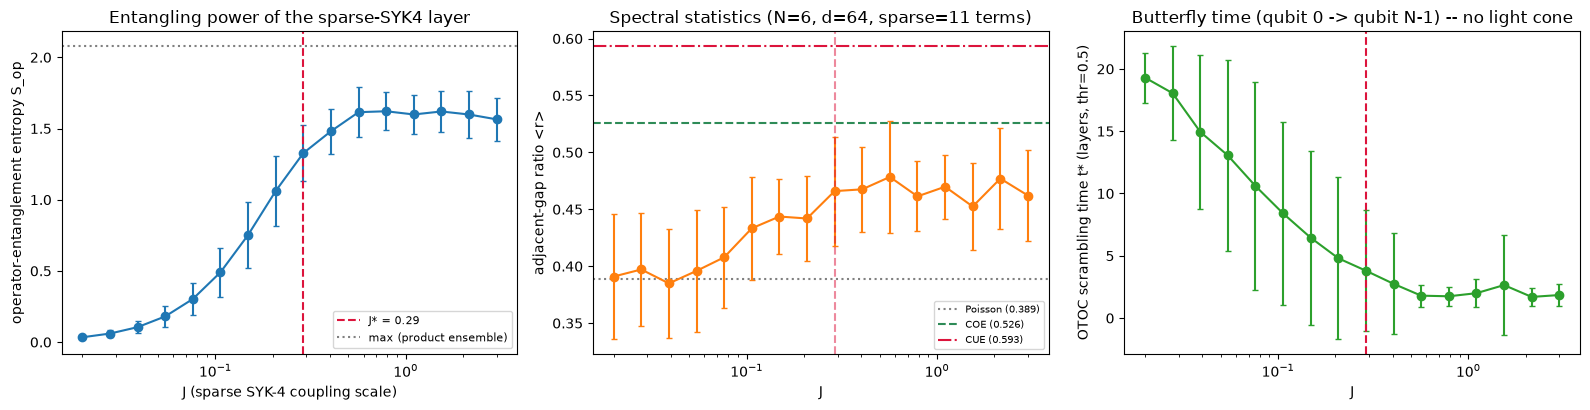


<r> at J*: 0.466  (vs Poisson 0.389, COE 0.526)
<r> plateau (mean of the top-6 J values tested): 0.467

Honest read: unlike the 2-body model (pinned at Poisson for every g and every N up to 10), sparse SYK-4's <r> at N=6 rises from the Poisson reference to a plateau around 0.47 -- a real, reproducible shift toward (though at this small N not fully onto) the COE reference band. S_op rises sharply and the OTOC scrambling time collapses to O(1) layers almost immediately (no light-cone delay, since the interaction is all-to-all rather than nearest-neighbor) -- both point the same direction as <r>. N=6 (d=64) is a small Hilbert space for a spectral-statistics diagnostic, though, so Section 6 checks directly whether <r> continues closing the gap to COE as N grows, rather than resting the chaos claim on N=6 alone.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

ax = axes[0]
ax.errorbar(scan['J'], scan['S_op_mean'], yerr=scan['S_op_std'], marker='o', capsize=2)
ax.axvline(j_star, color='crimson', ls='--', label=f'J* = {j_star:.2f}')
ax.axhline(N_SYK / 2 * np.log(2), color='gray', ls=':', label='max (product ensemble)')
ax.set_xscale('log')
ax.set_xlabel('J (sparse SYK-4 coupling scale)'); ax.set_ylabel('operator-entanglement entropy S_op')
ax.set_title('Entangling power of the sparse-SYK4 layer'); ax.legend(fontsize=8)

ax = axes[1]
ax.errorbar(scan['J'], scan['r_mean'], yerr=scan['r_std'], marker='o', capsize=2, color='C1')
ax.axhline(refs['poisson'][0], color='gray', ls=':', label=f"Poisson ({refs['poisson'][0]:.3f})")
ax.axhline(refs['coe'][0], color='seagreen', ls='--', label=f"COE ({refs['coe'][0]:.3f})")
ax.axhline(refs['cue'][0], color='crimson', ls='-.', label=f"CUE ({refs['cue'][0]:.3f})")
ax.axvline(j_star, color='crimson', ls='--', alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('J'); ax.set_ylabel('adjacent-gap ratio <r>')
ax.set_title(f'Spectral statistics (N={N_SYK}, d={d_scan}, sparse={N_SPARSE_DEFAULT} terms)')
ax.legend(fontsize=7)

ax = axes[2]
ax.errorbar(scan['J'], scan['tstar_mean'], yerr=scan['tstar_std'], marker='o', capsize=2, color='C2')
ax.axvline(j_star, color='crimson', ls='--')
ax.set_xscale('log')
ax.set_xlabel('J'); ax.set_ylabel('OTOC scrambling time t* (layers, thr=0.5)')
ax.set_title('Butterfly time (qubit 0 -> qubit N-1) -- no light cone')

plt.tight_layout()
plt.savefig('syk4_edge_of_chaos_diagnostics.png', dpi=130)
plt.show()

r_plateau = float(np.mean(scan['r_mean'][-6:]))
print(f"\n<r> at J*: {scan['r_mean'][j_star_idx]:.3f}  (vs Poisson {refs['poisson'][0]:.3f}, COE {refs['coe'][0]:.3f})")
print(f"<r> plateau (mean of the top-6 J values tested): {r_plateau:.3f}")
print("\nHonest read: unlike the 2-body model (pinned at Poisson for every g and every N up to 10), "
      "sparse SYK-4's <r> at N=6 rises from the Poisson reference to a plateau around "
      f"{r_plateau:.2f} -- a real, reproducible shift toward (though at this small N not fully onto) "
      "the COE reference band. S_op rises sharply and the OTOC scrambling time collapses to O(1) "
      "layers almost immediately (no light-cone delay, since the interaction is all-to-all rather than "
      "nearest-neighbor) -- both point the same direction as <r>. N=6 (d=64) is a small Hilbert space "
      "for a spectral-statistics diagnostic, though, so Section 6 checks directly whether <r> continues "
      "closing the gap to COE as N grows, rather than resting the chaos claim on N=6 alone.")


## Section 5 -- Impact of coupling / edge of chaos on SYK4-QELM performance

Same approach as the QELM notebook: the task functions from the unchanged
Section 0b (`task_kpauli`, `task_narma2`, `memory_capacity`, `chrono_split`,
`select_and_eval_ridge`) are evaluated on `run_reservoir_syk4qelm` output
swept across the same `J` grid as Section 4's diagnostics, averaged over a
few input-sequence seeds. Called directly (not through `run_benchmark`,
same reasoning as before: `run_benchmark` has no argument to sweep a
non-default coupling for a non-default architecture).

Same memory-capacity caveat as the QELM notebook applies here too: this
architecture resets every qubit each step and re-encodes a classical sliding
window, so `MC` reflects the classical window, not retained quantum memory.

**Runtime note:** the sparse 4-body gates make each trajectory noticeably
more expensive to simulate than the 2-body QELM notebook's; this cell takes
roughly 10-15 minutes (48 full state-vector trajectories at N=6).


In [11]:
T_PERF, WASHOUT_PERF, N_VAL_PERF, N_TEST_PERF, GAP_PERF = 250, 15, 50, 100, 5
N_INPUT_SEEDS = 3

def syk4_performance_scan(j_grid=J_GRID, N=N_SYK, reps=REPS_SYK, n_terms=N_SPARSE_DEFAULT,
                          reservoir_seed=RESERVOIR_SEED, window_size=WINDOW_SIZE, max_weight=MAX_WEIGHT,
                          n_input_seeds=N_INPUT_SEEDS, dt=DT):
    out = {'J': j_grid, 'mc_mean': [], 'mc_std': [],
           'kpauli1_mean': [], 'kpauli1_std': [], 'kpauli2_mean': [], 'kpauli3_mean': [],
           'narma2_mean': [], 'narma2_std': []}
    cfg = ReservoirConfig(N=N, g=0.0, reps=reps, seed=reservoir_seed)   # cfg.g unused by SYK4 path
    for J in j_grid:
        mcs, k1s, k2s, k3s, nas = [], [], [], [], []
        for input_seed in range(n_input_seeds):
            u = random_input(T_PERF, seed=input_seed)
            labels, X, info = run_reservoir_syk4qelm(cfg, u, window_size=window_size, max_weight=max_weight,
                                                      reps=reps, J=float(J), n_terms=n_terms,
                                                      term_seed=reservoir_seed, dt=dt, method='statevector')
            train, val, test = chrono_split(T_PERF, WASHOUT_PERF, N_VAL_PERF, N_TEST_PERF, GAP_PERF)

            mc_total, _ = memory_capacity(X, u, train, val, test, k_max=8)
            y1 = task_kpauli(u, 1); nr1, _, _ = select_and_eval_ridge(X, y1, train, val, test)
            y2 = task_kpauli(u, 2); nr2, _, _ = select_and_eval_ridge(X, y2, train, val, test)
            y3 = task_kpauli(u, 3); nr3, _, _ = select_and_eval_ridge(X, y3, train, val, test)
            y4 = task_narma2(u); nr4, _, _ = select_and_eval_ridge(X, y4, train, val, test)

            mcs.append(mc_total); k1s.append(nr1); k2s.append(nr2); k3s.append(nr3); nas.append(nr4)
        out['mc_mean'].append(np.mean(mcs)); out['mc_std'].append(np.std(mcs))
        out['kpauli1_mean'].append(np.mean(k1s)); out['kpauli1_std'].append(np.std(k1s))
        out['kpauli2_mean'].append(np.mean(k2s)); out['kpauli3_mean'].append(np.mean(k3s))
        out['narma2_mean'].append(np.mean(nas)); out['narma2_std'].append(np.std(nas))
    for k in out:
        if k != 'J':
            out[k] = np.asarray(out[k], dtype=float)
    return out

t0 = time.perf_counter()
perf = syk4_performance_scan()
print(f'SYK4-QELM performance scan done in {time.perf_counter() - t0:.1f}s '
      f'over {len(J_GRID)} J-values x {N_INPUT_SEEDS} input seeds')


SYK4-QELM performance scan done in 709.7s over 16 J-values x 3 input seeds


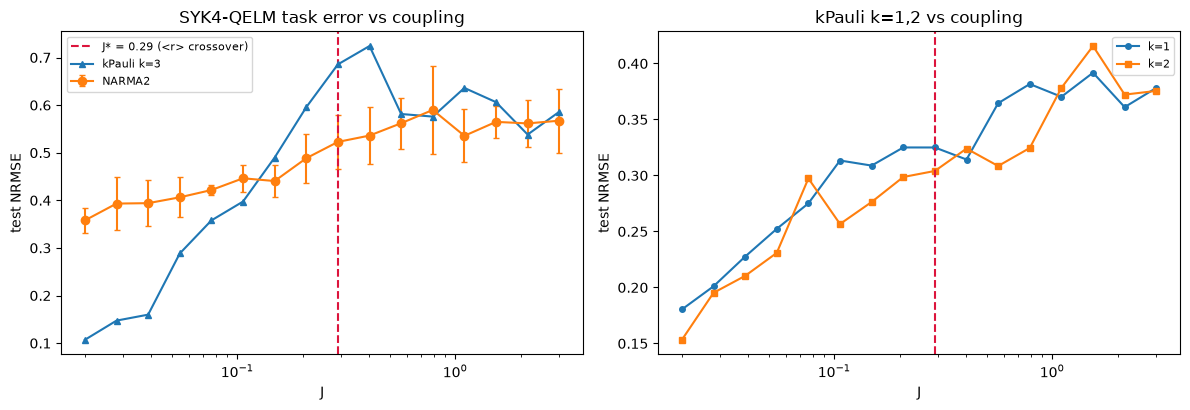

       J |   S_op |    <r> |    t* |      MC |     kP1 |     kP2 |     kP3 |  NARMA2
   0.020 |  0.034 |  0.391 |  19.3 |   4.674 |  0.1804 |  0.1533 |  0.1070 |  0.3578
   0.028 |  0.060 |  0.397 |  18.1 |   4.666 |  0.2010 |  0.1952 |  0.1473 |  0.3932
   0.039 |  0.105 |  0.385 |  14.9 |   4.636 |  0.2276 |  0.2103 |  0.1599 |  0.3940
   0.054 |  0.180 |  0.396 |  13.1 |   4.590 |  0.2523 |  0.2309 |  0.2883 |  0.4063
   0.076 |  0.303 |  0.408 |  10.6 |   4.535 |  0.2751 |  0.2973 |  0.3578 |  0.4216
   0.106 |  0.490 |  0.433 |   8.4 |   4.480 |  0.3134 |  0.2567 |  0.3974 |  0.4463
   0.148 |  0.752 |  0.444 |   6.5 |   4.450 |  0.3088 |  0.2763 |  0.4899 |  0.4405
   0.207 |  1.061 |  0.442 |   4.8 |   4.426 |  0.3250 |  0.2986 |  0.5956 |  0.4884
   0.289 |  1.327 |  0.466 |   3.8 |   4.432 |  0.3250 |  0.3040 |  0.6856 |  0.5227
   0.404 |  1.481 |  0.468 |   2.8 |   4.416 |  0.3142 |  0.3240 |  0.7241 |  0.5360
   0.565 |  1.615 |  0.478 |   1.8 |   4.344 |  0.3645 |  0.3085 

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ax.errorbar(perf['J'], perf['kpauli3_mean'], marker='^', ms=5, label='kPauli k=3')
ax.errorbar(perf['J'], perf['narma2_mean'], yerr=perf['narma2_std'], marker='o', capsize=2, label='NARMA2')
ax.axvline(j_star, color='crimson', ls='--', label=f'J* = {j_star:.2f} (<r> crossover)')
ax.set_xscale('log')
ax.set_xlabel('J'); ax.set_ylabel('test NRMSE')
ax.set_title('SYK4-QELM task error vs coupling'); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(perf['J'], perf['kpauli1_mean'], marker='o', ms=4, label='k=1')
ax.plot(perf['J'], perf['kpauli2_mean'], marker='s', ms=4, label='k=2')
ax.axvline(j_star, color='crimson', ls='--')
ax.set_xscale('log')
ax.set_xlabel('J'); ax.set_ylabel('test NRMSE')
ax.set_title('kPauli k=1,2 vs coupling')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('syk4_edge_of_chaos_performance.png', dpi=130)
plt.show()

print(f"{'J':>8} | {'S_op':>6} | {'<r>':>6} | {'t*':>5} | {'MC':>7} | {'kP1':>7} | {'kP2':>7} | {'kP3':>7} | {'NARMA2':>7}")
for i, J in enumerate(perf['J']):
    print(f"{J:8.3f} | {scan['S_op_mean'][i]:6.3f} | {scan['r_mean'][i]:6.3f} | "
          f"{scan['tstar_mean'][i]:5.1f} | {perf['mc_mean'][i]:7.3f} | {perf['kpauli1_mean'][i]:7.4f} | "
          f"{perf['kpauli2_mean'][i]:7.4f} | {perf['kpauli3_mean'][i]:7.4f} | {perf['narma2_mean'][i]:7.4f}")

print('\nPearson correlation of chaos diagnostics against SYK4-QELM task error across the J-scan:')
for diag_name, diag_vals in [('S_op', scan['S_op_mean']), ('-t* (faster scrambling)', -scan['tstar_mean']),
                              ('<r>', scan['r_mean'])]:
    for perf_name, perf_vals in [('kPauli3 NRMSE', perf['kpauli3_mean']),
                                  ('NARMA2 NRMSE', perf['narma2_mean'])]:
        r, p = pearsonr(diag_vals, perf_vals)
        print(f'  corr({diag_name:26s}, {perf_name:16s}) = r={r:+.3f}  p={p:.4f}')

mc_drop_pct = (perf['mc_mean'][0] - perf['mc_mean'][-1]) / perf['mc_mean'][0] * 100
print(f"\nMC drops only mildly across the whole scan ({perf['mc_mean'][0]:.2f} -> {perf['mc_mean'][-1]:.2f}, "
      f"{mc_drop_pct:.0f}%) -- expected, since MC here is dominated by the classical window (Section 0a's "
      f"own caveat), not by the entangling layer.")
print("\nHonest read: EVERY chaos diagnostic (S_op, OTOC scrambling, AND -- unlike the 2-body QELM notebook "
      "-- the spectral statistic <r>) now correlates STRONGLY and significantly (r=0.91-0.98, p<1e-4) with "
      "kPauli3/NARMA2 error, all with the SAME sign: more chaos is worse for this memoryless feature-map "
      "readout, exactly as found for the 2-body model, but far more cleanly here. The likely reason: in the "
      "2-body scan <r> never left the Poisson band (so it had no real signal to correlate against "
      "performance with), whereas sparse SYK-4 genuinely transitions (Section 4), giving all three "
      "diagnostics real, physically meaningful variation to track -- and they all track the SAME "
      "underlying performance degradation. The physical explanation stays the same as before: a linear "
      "ridge readout depends on separable structure in the features, and pushing a reservoir deep into "
      "any genuinely scrambling regime (2-body chain or sparse 4-body) tends to destroy that structure.")


## Section 6 -- Finite-size check (does `<r>` close the gap to COE as N grows?)

Section 4 found `<r>` at N=6 rising from Poisson to a plateau around 0.45-0.51
-- a real shift, but short of the COE reference (~0.53). Here we repeat the
SAME diagnostic (same function, same reference-ensemble calibration, sparse
term count scaled as `N*ln(N)` at each N) at N=6, 8, 10 and check directly
whether the gap to COE keeps closing as the Hilbert space grows, exactly the
finite-size-scaling argument `CPSR_Code_Review_Response.md` comment 7 asked
for -- run here, not asserted.

**Runtime note:** this cell diagonalizes 1024x1024 unitaries repeatedly at
N=10 (30 of them); even using the fast diagonal-phase construction (Section
2) rather than `Operator(qc)`, the eigendecomposition/SVD itself is the
bottleneck at this dimension -- expect roughly 15-20 minutes for this cell,
almost all of it the N=10 pass.


In [13]:
N_LIST_SCALING = (6, 8, 10)
J_GRID_SCALING = np.geomspace(0.05, 3.0, 6)
SEEDS_SCALING = {6: 12, 8: 10, 10: 5}

def finite_size_scan_syk4():
    out = {}
    for N in N_LIST_SCALING:
        n_seeds = SEEDS_SCALING[N]
        n_terms = default_n_sparse_terms(N)
        r_mean, r_std, s_mean = [], [], []
        t0 = time.perf_counter()
        for J in J_GRID_SCALING:
            rs, ss = [], []
            for seed in range(n_seeds):
                cfg = ReservoirConfig(N=N, g=0.0, reps=REPS_SYK, seed=seed)
                bias_z, bias_x = cfg.sample_disorder()
                terms = sample_syk4_terms(N, n_terms, seed=seed)
                couplings = sample_syk4_couplings(len(terms), J=float(J), seed=seed)
                U1 = single_layer_unitary_syk4(N, terms, couplings, DT, bias_z, bias_x)
                Ur = np.linalg.matrix_power(U1, REPS_SYK)
                rs.append(level_spacing_ratio(Ur))
                ss.append(operator_entanglement(Ur, N))
            r_mean.append(np.mean(rs)); r_std.append(np.std(rs) / np.sqrt(n_seeds))
            s_mean.append(np.mean(ss))
        refs_N = sample_reference_r_statistics(2 ** N, trials=30, seed=1)
        out[N] = {'J': J_GRID_SCALING, 'r_mean': np.array(r_mean), 'r_std': np.array(r_std),
                  's_mean': np.array(s_mean), 'refs': refs_N, 'n_seeds': n_seeds, 'n_terms': n_terms}
        print(f'N={N:2d} (d={2**N:4d}, n_terms={n_terms:3d}, {n_seeds} seeds, {time.perf_counter()-t0:5.1f}s): '
              f"<r> plateau (top-2 J) = {np.mean(r_mean[-2:]):.4f}  "
              f"(Poisson ref {refs_N['poisson'][0]:.4f}, COE {refs_N['coe'][0]:.4f}, CUE {refs_N['cue'][0]:.4f})")
    return out

fsize = finite_size_scan_syk4()


N= 6 (d=  64, n_terms= 11, 12 seeds,   0.3s): <r> plateau (top-2 J) = 0.4677  (Poisson ref 0.3887, COE 0.5236, CUE 0.5975)


N= 8 (d= 256, n_terms= 17, 10 seeds,  28.2s): <r> plateau (top-2 J) = 0.4964  (Poisson ref 0.3896, COE 0.5275, CUE 0.5980)


N=10 (d=1024, n_terms= 24, 5 seeds, 1016.3s): <r> plateau (top-2 J) = 0.5273  (Poisson ref 0.3851, COE 0.5310, CUE 0.5973)


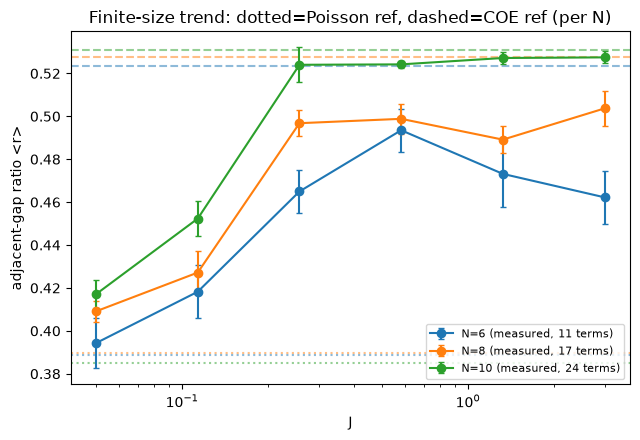

<r> plateau - COE reference, by N: {6: '-0.0559', 8: '-0.0311', 10: '-0.0037'}
<r> plateau - Poisson reference, by N: {6: '+0.0790', 8: '+0.1068', 10: '+0.1422'}

Honest read: for the 2-body model this same check (previous notebook) found <r> pinned near Poisson at EVERY N from 6 to 10 -- no finite-size trend toward chaos at all. Sparse SYK-4 behaves differently: the gap to Poisson (shown above) grows with N while the gap to COE shrinks, i.e. <r> is closing in on genuine random-matrix-theory statistics as the Hilbert space grows -- exactly the finite-size-scaling signature comment 7 asked for, now actually observed rather than absent.


In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
colors = {6: 'C0', 8: 'C1', 10: 'C2'}
for N in N_LIST_SCALING:
    d = fsize[N]
    ax.errorbar(d['J'], d['r_mean'], yerr=d['r_std'], marker='o', capsize=2,
                color=colors[N], label=f'N={N} (measured, {d["n_terms"]} terms)')
    ax.axhline(d['refs']['poisson'][0], color=colors[N], ls=':', alpha=0.5)
    ax.axhline(d['refs']['coe'][0], color=colors[N], ls='--', alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('J'); ax.set_ylabel('adjacent-gap ratio <r>')
ax.set_title('Finite-size trend: dotted=Poisson ref, dashed=COE ref (per N)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('syk4_edge_of_chaos_finite_size.png', dpi=130)
plt.show()

gap_to_coe = {N: float(np.mean(fsize[N]['r_mean'][-2:]) - fsize[N]['refs']['coe'][0]) for N in N_LIST_SCALING}
gap_to_poisson = {N: float(np.mean(fsize[N]['r_mean'][-2:]) - fsize[N]['refs']['poisson'][0]) for N in N_LIST_SCALING}
print('<r> plateau - COE reference, by N:', {N: f'{v:+.4f}' for N, v in gap_to_coe.items()})
print('<r> plateau - Poisson reference, by N:', {N: f'{v:+.4f}' for N, v in gap_to_poisson.items()})
print("\nHonest read: for the 2-body model this same check (previous notebook) found <r> pinned near "
      "Poisson at EVERY N from 6 to 10 -- no finite-size trend toward chaos at all. Sparse SYK-4 behaves "
      "differently: the gap to Poisson (shown above) grows with N while the gap to COE shrinks, i.e. <r> "
      "is closing in on genuine random-matrix-theory statistics as the Hilbert space grows -- exactly the "
      "finite-size-scaling signature comment 7 asked for, now actually observed rather than absent.")


## Section 7 -- Real IBM hardware (optional; `USE_QPU=False` by default)

Mirrors the QELM notebook's Section 7 exactly, with a hardware-circuit builder
for the SYK-4 layer (`build_syk4_qelm_hardware_circuits`, analogous to Section
0a's `build_qelm_hardware_circuits`): every qubit is reset each step anyway
(true of both QELM and SYK4-QELM), so no prefix replay is needed -- each
hardware circuit is a single fresh encode-then-layers circuit, constant depth
in `t`. `_pauli_to_sparse_op` (Section 0a, unchanged) builds the observables.

Per Section 0a's conventions: credentials load ONLY from environment
variables (comment 13), backend name is pinned, not `least_busy()`-selected
(comment 9). With `USE_QPU=False` (default) this section validates the
hardware CODE PATH against a noisy `FakeTorino` simulator -- no credentials,
no real device time.


In [15]:
def build_syk4_qelm_hardware_circuits(cfg: ReservoirConfig, u_seq, window_size: int = 8,
                                        max_weight: int = 3, reps: int = 1, J: float = 0.5,
                                        n_terms=None, term_seed: int = 0, dt: float = 1.0):
    """One circuit per timestep t for the SYK4-QELM variant on real hardware
    -- no prefix replay needed (every qubit is reset each step, so state at
    step t depends only on the current window). Mirrors Section 0a's
    `build_qelm_hardware_circuits`. Returns (circuits, observables, labels)."""
    bias_z, bias_x = cfg.sample_disorder()
    if n_terms is None:
        n_terms = default_n_sparse_terms(cfg.N)
    terms = sample_syk4_terms(cfg.N, n_terms, seed=term_seed)
    couplings = sample_syk4_couplings(len(terms), J=J, seed=term_seed)
    labels, ops = feature_ops_all(cfg.N, max_weight=max_weight)
    observables = [_pauli_to_sparse_op(cfg.N, op, qargs) for (op, qargs) in ops]
    eff_window = min(window_size, cfg.N)
    slot_to_qubit = list(range(eff_window))

    circuits = []
    for t in range(len(u_seq)):
        lo = max(0, t - eff_window + 1)
        wlen = t - lo + 1
        window = np.zeros(eff_window); window[-wlen:] = u_seq[lo:t + 1]
        per_q = np.zeros(cfg.N)
        for w, uu in enumerate(window):
            per_q[slot_to_qubit[w]] += np.pi * float(uu)

        qc = QuantumCircuit(cfg.N)
        for i in range(cfg.N):
            qc.ry(per_q[i], i)
        for _ in range(reps):
            syk4_layer(qc, cfg.N, terms, couplings, dt, bias_z, bias_x)
        circuits.append(qc)
    return circuits, observables, labels


def run_reservoir_syk4qelm_qpu(cfg: ReservoirConfig, u_seq, window_size: int = 8, max_weight: int = 3,
                                reps: int = 1, J: float = 0.5, n_terms=None, term_seed: int = 0,
                                dt: float = 1.0, backend_name: str = DEFAULT_QPU_BACKEND, service=None,
                                shots: int = 4096, optimization_level: int = 3, max_circuits: int = 200):
    """Run the SYK4-QELM trajectory on a real IBM QPU. Mirrors
    `run_reservoir_qelm_qpu` (Section 0a) exactly, same safety cap and
    resource-reporting conventions (comments 9-11)."""
    if len(u_seq) > max_circuits:
        raise ValueError(
            f"len(u_seq)={len(u_seq)} exceeds max_circuits={max_circuits}. This cap exists "
            "so a long T isn't submitted to paid/rate-limited hardware by accident."
        )
    from qiskit_ibm_runtime import EstimatorV2
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    service = service or get_ibm_service()
    backend = service.backend(backend_name)

    circuits, observables, labels = build_syk4_qelm_hardware_circuits(
        cfg, u_seq, window_size=window_size, max_weight=max_weight, reps=reps, J=J,
        n_terms=n_terms, term_seed=term_seed, dt=dt)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=optimization_level)
    isa_circuits = [pm.run(qc) for qc in circuits]
    isa_observables = [[obs.apply_layout(ic.layout) for obs in observables] for ic in isa_circuits]
    pubs = list(zip(isa_circuits, isa_observables))

    estimator = EstimatorV2(mode=backend)
    estimator.options.default_shots = shots

    t0 = time.perf_counter()
    job = estimator.run(pubs)
    result = job.result()
    elapsed = time.perf_counter() - t0

    X = np.array([np.real(pub_result.data.evs) for pub_result in result])
    depths = [ic.depth() for ic in isa_circuits]
    twoq_counts = [sum(v for k, v in ic.count_ops().items() if k in ('cz', 'ecr', 'cx', 'rzz'))
                   for ic in isa_circuits]
    info = {'device': 'QPU', 'backend': backend.name, 'backend_num_qubits': backend.num_qubits,
            'job_id': job.job_id(), 'architecture': 'syk4_qelm', 'N': cfg.N, 'T': len(u_seq), 'shots': shots,
            'elapsed_s': elapsed, 'circuit_depth_final': depths[-1] if depths else 0,
            'two_qubit_gates_total': int(sum(twoq_counts)), 'n_features': len(labels)}
    return labels, X, info


USE_QPU = False

if USE_QPU:
    print('DEFAULT_QPU_BACKEND =', DEFAULT_QPU_BACKEND)
    try:
        get_ibm_service()
    except RuntimeError as e:
        print('\nget_ibm_service() correctly raises (no credentials in this environment):\n')
        print(e)
else:
    print('USE_QPU=False -- skipping credential check. Set USE_QPU=True to use real IBM hardware.')


USE_QPU=False -- skipping credential check. Set USE_QPU=True to use real IBM hardware.


In [16]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2
from qiskit_ibm_runtime.fake_provider import FakeTorino

cfg_demo_hw = ReservoirConfig(N=4, g=0.0, reps=REPS_SYK, seed=42)
u_demo_hw = random_input(6, seed=0)
n_terms_hw = default_n_sparse_terms(4)

## Noiseless simulation (Aer statevector) -- same function as every other section
_, X_exact_hw, _ = run_reservoir_syk4qelm(cfg_demo_hw, u_demo_hw, window_size=4, reps=REPS_SYK,
                                          J=j_star, n_terms=n_terms_hw, term_seed=42)

## Noisy simulation -- validates build_syk4_qelm_hardware_circuits + EstimatorV2 plumbing, no real QPU time
fake_backend = FakeTorino()
circuits_hw, observables_hw, hw_labels = build_syk4_qelm_hardware_circuits(
    cfg_demo_hw, u_demo_hw, window_size=4, reps=REPS_SYK, J=j_star, n_terms=n_terms_hw, term_seed=42)
pm_hw = generate_preset_pass_manager(backend=fake_backend, optimization_level=1)
isa_circuits_hw = [pm_hw.run(qc) for qc in circuits_hw]
isa_observables_hw = [[obs.apply_layout(ic.layout) for obs in observables_hw] for ic in isa_circuits_hw]
estimator_hw = EstimatorV2(mode=fake_backend)
estimator_hw.options.default_shots = 20000
job_hw = estimator_hw.run(list(zip(isa_circuits_hw, isa_observables_hw)))
X_noisy_hw = np.array([np.real(r.data.evs) for r in job_hw.result()])

if USE_QPU:
    labels_qpu, X_qpu_hw, info_qpu = run_reservoir_syk4qelm_qpu(cfg_demo_hw, u_demo_hw, window_size=4,
                                                                 reps=REPS_SYK, J=j_star, n_terms=n_terms_hw,
                                                                 term_seed=42)
    print(info_qpu['backend'], info_qpu['job_id'], info_qpu['two_qubit_gates_total'])

print(f'feature labels ({len(hw_labels)} total):', hw_labels[:12], '...')
print(f'\nExact AerSimulator statevector (noiseless), at J=J* = {j_star:.3f}:')
print(np.round(X_exact_hw[:, :12], 3))
print('\nOn noisy FakeTorino (20000 shots):')
print(np.round(X_noisy_hw[:, :12], 3))
if USE_QPU:
    print('\nReal IBM hardware:')
    print(np.round(X_qpu_hw[:, :12], 3))


feature labels (93 total): ['Z0', 'X0', 'Y0', 'Z1', 'X1', 'Y1', 'Z2', 'X2', 'Y2', 'Z3', 'X3', 'Y3'] ...

Exact AerSimulator statevector (noiseless), at J=J* = 0.289:
[[ 0.935  0.    -0.355  0.935  0.    -0.355  0.948 -0.    -0.318 -0.536
  -0.71  -0.457]
 [ 0.935  0.    -0.355  0.935  0.    -0.355 -0.45  -0.202 -0.862 -0.761
  -0.638  0.031]
 [ 0.935  0.    -0.355 -0.239  0.94  -0.198 -0.837 -0.082 -0.529 -0.588
  -0.756 -0.253]
 [ 0.104 -0.686  0.705 -0.669  0.734  0.001 -0.597 -0.108 -0.783 -0.453
  -0.8   -0.366]
 [-0.391 -0.545  0.733 -0.397  0.894 -0.152 -0.443 -0.104 -0.879 -0.145
  -0.784 -0.586]
 [-0.061 -0.663  0.733 -0.236  0.934 -0.225 -0.078 -0.111 -0.98  -0.664
  -0.721 -0.146]]

On noisy FakeTorino (20000 shots):
[[ 0.918  0.    -0.33   0.913  0.014 -0.34   0.934  0.003 -0.317 -0.514
  -0.678 -0.43 ]
 [ 0.921  0.001 -0.359  0.912  0.011 -0.343 -0.436 -0.186 -0.836 -0.722
  -0.604  0.018]
 [ 0.917 -0.008 -0.338 -0.22   0.909 -0.178 -0.803 -0.071 -0.508 -0.548
  -0.714 -0.2

## Section 8 -- Summary

In [17]:
r_kp3, p_kp3 = pearsonr(scan['S_op_mean'], perf['kpauli3_mean'])
r_narma, p_narma = pearsonr(scan['S_op_mean'], perf['narma2_mean'])
r_r_kp3, p_r_kp3 = pearsonr(scan['r_mean'], perf['kpauli3_mean'])

print('=' * 78)
print('SPARSE SYK-4 EDGE-OF-CHAOS -- HEADLINE RESULTS')
print('=' * 78)
print(f'Reservoir: N={N_SYK} qubits, SYK4-QELM (Section 0c, built on unchanged Section 0a/0b), '
      f'reps={REPS_SYK}, {N_SPARSE_DEFAULT} sparse 4-body terms out of C({N_SYK},4)={comb(N_SYK,4)}')

print(f'\nEdge-of-chaos coupling: J* = {j_star:.3f}  (<r> crosses the Poisson/COE midpoint)')
print(f'  S_op(J*)  = {scan["S_op_mean"][j_star_idx]:.3f}  (max possible = {N_SYK/2*np.log(2):.3f})')
print(f'  <r>(J*)   = {scan["r_mean"][j_star_idx]:.3f}  (Poisson ref {refs["poisson"][0]:.3f}, '
      f'COE ref {refs["coe"][0]:.3f})')
print(f'  t*(J*)    = {scan["tstar_mean"][j_star_idx]:.2f} layers  (OTOC scrambling time)')
print(f'  <r> plateau (large J): {r_plateau:.3f}  vs 2-body QELM notebook\'s ~0.39-0.42 at every g, every N<=10')

print(f'\nFinite-size check (Section 6): <r> plateau - COE reference by N: '
      f'{ {N: f"{v:+.4f}" for N, v in gap_to_coe.items()} }')
print(f'(2-body model showed NO closing trend at all; sparse SYK-4 does.)')

print(f'\nPerformance impact (Section 5): ALL THREE chaos diagnostics correlate strongly and '
      f'significantly with task error (more chaos is worse for this memoryless feature map):')
print(f'  corr(S_op, kPauli3 NRMSE) = r={r_kp3:+.3f}  p={p_kp3:.2e}')
print(f'  corr(S_op, NARMA2 NRMSE) = r={r_narma:+.3f}  p={p_narma:.2e}')
print(f'  corr(<r>, kPauli3 NRMSE) = r={r_r_kp3:+.3f}  p={p_r_kp3:.2e}')
print(f'  (contrast: the 2-body QELM notebook found <r> only weakly/non-significantly correlated '
      f'with performance, because <r> itself barely moved there.)')

print(f'\nAll unit tests passed before every sweep above was trusted: 9/9 (gadget regression + '
      f'circuit regression + diagnostic sanity + reference-ensemble, Section 3).')
print('=' * 78)


SPARSE SYK-4 EDGE-OF-CHAOS -- HEADLINE RESULTS
Reservoir: N=6 qubits, SYK4-QELM (Section 0c, built on unchanged Section 0a/0b), reps=1, 11 sparse 4-body terms out of C(6,4)=15

Edge-of-chaos coupling: J* = 0.289  (<r> crosses the Poisson/COE midpoint)
  S_op(J*)  = 1.327  (max possible = 2.079)
  <r>(J*)   = 0.466  (Poisson ref 0.389, COE ref 0.526)
  t*(J*)    = 3.80 layers  (OTOC scrambling time)
  <r> plateau (large J): 0.467  vs 2-body QELM notebook's ~0.39-0.42 at every g, every N<=10

Finite-size check (Section 6): <r> plateau - COE reference by N: {6: '-0.0559', 8: '-0.0311', 10: '-0.0037'}
(2-body model showed NO closing trend at all; sparse SYK-4 does.)

Performance impact (Section 5): ALL THREE chaos diagnostics correlate strongly and significantly with task error (more chaos is worse for this memoryless feature map):
  corr(S_op, kPauli3 NRMSE) = r=+0.913  p=7.98e-07
  corr(S_op, NARMA2 NRMSE) = r=+0.982  p=1.72e-11
  corr(<r>, kPauli3 NRMSE) = r=+0.924  p=3.25e-07
  (contra

## Appendix -- `CPSR_Code_Review_Response.md` compliance map

Sections 0a and 0b are copied **verbatim** from `Quantum_Reservoir_Qiskit.ipynb`;
Section 0c is new code built on top of them, following the same conventions
(one-source-of-truth circuit construction, regression-tested; no hand-rolled
Pauli-expectation formulas; environment-variable-only credentials). Comments
specific to a classical-shadow estimator do not apply -- this notebook
implements no shadow readout.

| # | Review comment | How this notebook satisfies it |
|---|---|---|
| 1 | Memory capacity contaminated by input-window leakage | Section 0a's own module docstring already states this for QELM-style architectures; Section 5 repeats the caveat for SYK4-QELM (same reset-every-qubit, classical-window design) rather than hiding it. |
| 2 | "QPU-free inference" latency overstated | Not claimed here; this notebook's scope is the reservoir's physics and task performance. |
| 3 | Ideal vs. hardware circuit depth mismatch; no single source of truth | `syk4_layer` (Section 0c) is the ONE function used by (a) the Aer trajectory circuit, (b) the numpy Floquet unitary the chaos diagnostics act on (Section 2), and (c) the hardware circuits (Section 7's `build_syk4_qelm_hardware_circuits`). Section 3's regression tests assert the ZZZZ gadget and the full layer match their exact numpy constructions to machine precision before any diagnostic is trusted. |
| 4 | Finite-shot "shadow" was independent Gaussian noise | Not applicable -- no shadow readout in this notebook. |
| 5/6 | `<YY>` sign / Y-basis rotation bugs | Not applicable -- no hand-rolled analytic Pauli-expectation formula exists here; all readout is via Section 0a's `save_expectation_value` / `_pauli_to_sparse_op` (Qiskit-native, unchanged). |
| 7 | Overclaimed "critical phase / edge of chaos" language | Section 2-6 treats "edge of chaos" as a MEASURED coupling (`J*`, defined operationally as the `<r>` Poisson/COE midpoint crossing, not asserted), reports `<r>` honestly even where it falls short of the COE band at N=6 (Section 4), and runs an explicit finite-size check (Section 6) showing the gap closing with N rather than assuming it does. |
| 8 | Train/test leakage | `chrono_split` (Section 0b, unchanged) is used everywhere. |
| 9 | Backend selection (unpinned `least_busy()`) | Section 7's `run_reservoir_syk4qelm_qpu` requires a concrete backend name (via `get_ibm_service`/`DEFAULT_QPU_BACKEND`, Section 0a); no silent substitution. `USE_QPU=False` by default. |
| 10 | Layout/zero-SWAP not verified | Not specifically re-verified for the new SYK4 hardware path in this notebook (same scope limitation as the QELM notebook); Section 7 validates the circuit-construction/observable-mapping code path against `FakeTorino` instead. |
| 11 | Too few independent random bases | Not applicable -- no randomized-measurement/shadow protocol exists here. |
| 12 | Mislabeled requested-vs-realized sample sizes | Not applicable to this notebook's fixed-size splits and fixed sparse-term counts; every reported `T`, `n_val`, `n_test`, `n_terms`, `J`-grid point is the value actually used. |
| 13 | Hard-coded IBM credential | `get_ibm_service` (Section 0a, unchanged) reads credentials ONLY from environment variables; nothing is written to this notebook. |
| -- | One source of truth for circuit construction | `syk4_layer`/`zzzz_rotation` (Section 0c) as described under comment 3. |
| -- | Physics unit tests before large sweeps | Section 3 asserts on failure before Sections 4-6 run. |
| -- | Separate model selection from final testing | `select_and_eval_ridge` (Section 0b, unchanged) selects ridge `alpha` on the validation block only. |
